# Data Mining II (Spring Semester 2025-2026)
---
## Project: Reach for Change | Predicting Donor Response to Optimize Outreach for Social Good
**Group:** TBD  
**Authors:**
* João Galamba - 20250131
* Tamara Arakelyan - 20250290
* Thiago Bellas - 20231131

---


## <b><span style='color:#e61227'></span>Predicting Donor Response to Optimize Outreach for Social Good</b>


# <b><span style='color:#e61227'></span> Introduction<b>


## <b><span style='color:#e61227'></span> Purpose<b>

The main goal of this project is to predict whether a donor will respond positively to a future campaign, while keeping the full modeling workflow transparent and reproducible. The metodology follows a strict separation between **training**, **validation**, and **internal test** data. This design was chosen to avoid optimistic model selection and to make the final performance estimate more credible.

The independent Kaggle test file is only used after model development is complete, exactly as expected in a realistic deployment setting.


## <b><span style='color:#e61227'></span> What this notebook aims to demonstrate<b>

1. A clear and justified preprocessing strategy.
2. A concise but meaningful exploratory analysis **focused on decision-making**.
3. A classification pipeline based on methods covered in class.
4. A model assessment strategy aligned with the project guidelines and the Kaggle F1 objective.
5. A transparent optimization procedure that includes both hyperparameter tuning and probability-threshold selection.
6. An open-ended analytical section that goes beyond simply fitting a predictive pipeline.



## <b><span style='color:#e61227'></span> Methodological summary<b>

- **Input data**: `donors_train.csv` for model development and `donors_test.csv` for final prediction.
- **Target**: `TARGET_B`.
- **Identifier excluded from modeling**: `CONTROL_NUMBER`.
- **Assessment design**: internal **train / validation / test** split.
- **Selection metric**: **F1 score**, because the competition is ranked with binary F1 and the class distribution is imbalanced.
- **Candidate models**: Logistic Regression, Decision Tree, Random Forest, and Extra Trees.
- **Final deployment step**: refit the chosen configuration on train + validation, freeze the validation-selected threshold, and produce Kaggle predictions for the unseen test file.



# <b><span style='color:#e61227'></span> Project Development<b>

### <b><span style='color:#e61227'></span> Reading guide<b>

Each section starts with a short statement of purpose, followed by code and then interpretation.

The notebook is intentionally written so that a first-time reader can understand not only **what** is done, but also **why** each decision was made.


---


## <b><span style='color:#e61227'></span> 1. Imports and notebook global configuration<b>

This section gathers all libraries, metrics, and global constants used throughout the notebook.

### <b><span style='color:#e61227'></span> Why centralize imports?<b>

Centralizing imports improves readability and reproducibility. A reviewer should be able to inspect one cell and immediately understand:

- which packages are required,
- which modeling families are being considered,
- which evaluation metrics drive the project,
- and which random seed ensures reproducibility.

### <b><span style='color:#e61227'></span> Design principles followed here<b>

- Only **vanilla scikit-learn** models and utilities are used, which keeps the notebook aligned with the project restrictions.
- The configuration uses a fixed `RANDOM_STATE` so that splits and stochastic algorithms can be replicated.
- Performance metrics are imported explicitly instead of being called indirectly, making the evaluation protocol transparent.
- Plot defaults are configured once to keep visual output consistent and uncluttered.



In [0]:
# Silence non-critical warnings to keep notebook output readable during presentation.
import warnings
warnings.filterwarnings('ignore')

# Core scientific Python stack.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn utilities for mixed-type preprocessing and reproducible pipelines.
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from sklearn.model_selection import GridSearchCV

# Metrics selected to support threshold-dependent and threshold-independent assessment.
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    average_precision_score
)

# Model inspection utility used in the open-ended section.
from sklearn.inspection import permutation_importance

# Candidate algorithms explored in the benchmark.
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier, StackingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

# Global constants used throughout the notebook for reproducibility and readability.
RANDOM_STATE = 42
TARGET = 'TARGET_B'
ID_COL = 'CONTROL_NUMBER'

# Plot configuration chosen for consistent visual output.
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.grid'] = True



## <b><span style='color:#e61227'></span> 2. Loading the real project data<b>

The first operational step is to read the original CSV files supplied for the project.

`donors_train.csv`

`donors_test.csv`

### <b><span style='color:#e61227'></span> Why start from the raw files?<b>

For reproducibility, it is important that the notebook begins from the real data sources rather than from an already processed object. This makes the workflow auditable from the first step and helps verify that:

- the notebook can run end to end,
- the same logic is applied every time,
- and no hidden preprocessing is occurring outside the notebook.

At this stage we only inspect the dataset dimensions and preview a few rows. This is enough to confirm that the files were loaded correctly, without mixing exploration and preprocessing too early.



In [0]:
# Define the file paths for the labeled development data and the unlabeled Kaggle test data.
train_path = 'donors_train.csv'
test_path = 'donors_test.csv'

# Load the original CSV files exactly as provided for the project.
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# Quick structural validation: dimensions should be consistent with expectations.
print('Train shape:', train_df.shape)
print('Test shape :', test_df.shape)

# Display the first rows to verify that variables were read correctly.
train_df.head()


Train shape: (13560, 41)
Test shape : (5812, 40)


,CONTROL_NUMBER,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,LIFETIME_GIFT_AMOUNT,LIFETIME_GIFT_COUNT,LIFETIME_MAX_GIFT_AMT,LIFETIME_MIN_GIFT_AMT,LIFETIME_PROM,MEDIAN_HOME_VALUE,MEDIAN_HOUSEHOLD_INCOME,MONTHS_SINCE_FIRST_GIFT,MONTHS_SINCE_LAST_GIFT,MONTHS_SINCE_LAST_PROM_RESP,NUMBER_PROM_12,PCT_ATTRIBUTE1,PCT_ATTRIBUTE2,PCT_ATTRIBUTE3,PCT_ATTRIBUTE4,PCT_OWNER_OCCUPIED,PEP_STAR,PER_CAPITA_INCOME,RECENCY_STATUS_96NK,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING,TARGET_B
0,61745,4.0,3.0,33.0,M,0.0,1.0,H,5.0,20.0,9.0,35.0,2.0,20.0,15.0,21.0,566.0,315.0,182.037132,18.0,18.0,10.0,0.0,52.0,17.0,25.0,92.0,0.0,12827.0,A,0.00,17.50,NaN,0.000,2.0,0.154,0.0,2,T,NaN,1
1,112703,3.0,2.0,NaN,F,1.0,1.0,U,NaN,15.0,6.0,15.0,1.0,15.0,15.0,15.0,318.0,148.0,24.000000,24.0,24.0,7.0,0.0,31.0,31.0,39.0,73.0,0.0,7787.0,N,15.00,15.00,1.0,0.250,1.0,0.100,0.0,3,R,NaN,1
2,166437,4.0,2.0,NaN,F,7.0,3.0,H,4.0,10.0,17.0,79.0,11.0,12.0,5.0,40.0,1669.0,373.0,129.000000,15.0,15.0,8.0,0.0,26.0,39.0,38.0,84.0,1.0,13965.0,S,0.00,10.67,0.0,0.000,3.0,0.231,1.0,1,U,NaN,0
3,170621,4.0,NaN,61.0,M,13.0,1.0,H,6.0,11.0,28.0,80.0,17.0,11.0,3.0,75.0,1464.0,488.0,130.000000,16.0,16.0,13.0,0.0,48.0,30.0,44.0,84.0,1.0,24123.0,A,10.00,10.00,2.0,0.286,2.0,0.111,0.0,1,U,NaN,0
4,44428,6.0,0.0,75.0,M,3.0,4.0,H,3.0,7.0,9.0,27.0,5.0,7.0,5.0,22.0,936.0,249.0,24.000000,17.0,17.0,13.0,0.0,52.0,NaN,66.0,90.0,1.0,15008.0,N,5.67,5.40,3.0,0.600,5.0,0.500,0.0,2,C,NaN,0


## <b><span style='color:#e61227'></span> 3. Exploratory data analysis (EDA) and rule-based data cleaning<b>

Before building any model, the project needs a transparent data-quality audit. In this dataset, several variables represent counts, elapsed months, percentages, or gift amounts. Those semantic roles imply natural domain constraints. If such constraints are violated, the modeling pipeline may learn from artifacts rather than donor behavior.

### Why place this section before modeling?

This step is intentionally positioned early because it serves two objectives at once:

1. **Exploratory diagnosis** — understand what kinds of quality issues exist in the raw files.
2. **Defensible cleaning** — correct only what can be justified by clear domain logic, without using target information.

### Cleaning philosophy adopted in this notebook

The goal is **not** to aggressively manipulate the data until it looks perfect. Instead, the notebook applies a conservative strategy:

- obvious placeholders such as `?` are converted to genuine missing values,
- impossible values are replaced with `NaN` rather than guessed,
- discrete variables are kept discrete,
- contradictory donor-history relationships are flagged and neutralized,
- and every rule is documented so that the preprocessing remains explainable.

This is appropriate in an data science project setting because it prioritizes methodological clarity and avoids introducing undocumented assumptions.

### What the diagnostic will explicitly check

The audit below reproduces the main discrepancies identified in the raw training data and converts them into a structured quality report.

#### 1. Missingness profile
Some variables contain substantial missingness, especially socio-economic descriptors such as wealth, income group, and donor age. This matters because dropping incomplete rows would waste too much data.

#### 2. Impossible negative values
Variables such as donation counts, gift amounts, elapsed months, and per-capita income should not be negative in this business context. Negative values are therefore treated as invalid observations, not as meaningful signal.

#### 3. Percentages outside the 0–100 range
Percentage-style variables should remain within a closed interval. Values below 0 or above 100 are treated as data-quality failures.

#### 4. Discrete variables stored with decimal values
Several variables appear to encode counts, ratings, or ordinal groups. For those columns, non-integer values are suspicious. The notebook uses a two-part rule: values that are numerically very close to an integer are rounded, while genuinely fractional values are set to missing.

#### 5. Logical contradictions across related variables
Donation-history fields should be internally coherent. For example, the minimum lifetime gift cannot exceed the maximum lifetime gift; the last gift cannot exceed the lifetime maximum; and the number of recent card responses cannot exceed the total number of recent responses.

### Why convert invalid values to `NaN` instead of forcing corrections?

Because most contradictions do not reveal the correct value. Replacing them with `NaN` is more honest than fabricating a number, and the downstream pipelines already include imputation in a leakage-safe way.



In [0]:
# Create immutable copies of the raw files so that the audit remains reproducible.
train_raw = train_df.copy()
test_raw = test_df.copy()

In [0]:
# Standardize obvious placeholder missing values before auditing.
placeholder_tokens = ['?', 'NA', 'N/A', '', ' ']
train_raw = train_raw.replace(placeholder_tokens, np.nan)
test_raw = test_raw.replace(placeholder_tokens, np.nan)

In [0]:
# Variable groups derived from domain meaning.
non_negative_cols = [
    'CHILDREN', 'DONOR_AGE', 'FILE_CARD_GIFT', 'INCOME_GROUP',
    'LIFETIME_CARD_PROM', 'LIFETIME_GIFT_AMOUNT', 'LIFETIME_GIFT_COUNT',
    'LIFETIME_MAX_GIFT_AMT', 'LIFETIME_MIN_GIFT_AMT', 'MONTHS_SINCE_FIRST_GIFT',
    'MONTHS_SINCE_LAST_GIFT', 'MONTHS_SINCE_LAST_PROM_RESP', 'NUMBER_PROM_12',
    'CARD_PROM_12', 'RECENT_CARD_RESPONSE_COUNT', 'RECENT_RESPONSE_COUNT',
    'RECENT_AVG_CARD_GIFT_AMT', 'RECENT_AVG_GIFT_AMT', 'RECENT_CARD_RESPONSE_PROP',
    'RECENT_RESPONSE_PROP', 'LAST_GIFT_AMT', 'PEP_STAR', 'WEALTH_RATING',
    'PER_CAPITA_INCOME'
]

percent_cols = [
    'PCT_ATTRIBUTE1', 'PCT_ATTRIBUTE2', 'PCT_ATTRIBUTE3',
    'PCT_ATTRIBUTE4', 'PCT_OWNER_OCCUPIED'
]

discrete_cols = [
    'CARD_PROM_12', 'CHILDREN', 'DONOR_AGE', 'FILE_CARD_GIFT',
    'FREQUENCY_STATUS_97NK', 'INCOME_GROUP', 'LIFETIME_CARD_PROM',
    'LIFETIME_GIFT_COUNT', 'LIFETIME_PROM', 'MONTHS_SINCE_LAST_GIFT',
    'MONTHS_SINCE_LAST_PROM_RESP', 'NUMBER_PROM_12', 'PEP_STAR',
    'RECENT_CARD_RESPONSE_COUNT', 'RECENT_RESPONSE_COUNT', 'RECENT_STAR_STATUS',
    'WEALTH_RATING'
]

categorical_unknown_map = {
    'DONOR_GENDER': ['U'],
    'HOME_OWNER': ['U'],
    'SES': ['?'],
    'URBANICITY': ['?']
}

In [0]:
# Ensure the columns inspected as numeric are indeed numeric when possible.
def force_numeric(df, columns):
    out = df.copy()
    for col in columns:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors='coerce')
    return out

train_raw = force_numeric(train_raw, sorted(set(non_negative_cols + percent_cols + discrete_cols + [
    'LIFETIME_MIN_GIFT_AMT', 'LIFETIME_MAX_GIFT_AMT', 'LAST_GIFT_AMT',
    'LIFETIME_GIFT_AMOUNT', 'MONTHS_SINCE_FIRST_GIFT', 'RECENT_CARD_RESPONSE_COUNT',
    'RECENT_RESPONSE_COUNT', 'RECENT_AVG_CARD_GIFT_AMT', 'RECENT_AVG_GIFT_AMT'
])))

In [0]:
# Deterministic DQ Function
def audit_data_quality(df):
    rows = []

    # Missingness by column.
    missing_pct = df.isna().mean().mul(100)
    for col, pct in missing_pct[missing_pct > 0].sort_values(ascending=False).items():
        rows.append({'issue_type': 'missing_values', 'column': col, 'count': int(df[col].isna().sum()), 'detail': f'{pct:.2f}% missing'})

    # Negative values in columns expected to be non-negative.
    for col in non_negative_cols:
        if col in df.columns:
            mask = df[col].notna() & (df[col] < 0)
            if mask.any():
                rows.append({'issue_type': 'negative_value', 'column': col, 'count': int(mask.sum()), 'detail': 'Value below 0 in a non-negative field'})

    # Percentages outside domain.
    for col in percent_cols:
        if col in df.columns:
            mask = df[col].notna() & ((df[col] < 0) | (df[col] > 100))
            if mask.any():
                rows.append({'issue_type': 'percentage_out_of_range', 'column': col, 'count': int(mask.sum()), 'detail': 'Expected interval is [0, 100]'})

    # Decimal values in discrete columns.
    for col in discrete_cols:
        if col in df.columns:
            mask = df[col].notna() & ~np.isclose(df[col], np.round(df[col]), atol=1e-6)
            if mask.any():
                rows.append({'issue_type': 'non_integer_discrete_value', 'column': col, 'count': int(mask.sum()), 'detail': 'Discrete-looking field contains fractional values'})

    # Logical contradictions.
    contradiction_rules = {
        'min_greater_than_max': df['LIFETIME_MIN_GIFT_AMT'].notna() & df['LIFETIME_MAX_GIFT_AMT'].notna() & (df['LIFETIME_MIN_GIFT_AMT'] > df['LIFETIME_MAX_GIFT_AMT']),
        'last_greater_than_lifetime_max': df['LAST_GIFT_AMT'].notna() & df['LIFETIME_MAX_GIFT_AMT'].notna() & (df['LAST_GIFT_AMT'] > df['LIFETIME_MAX_GIFT_AMT']),
        'lifetime_amount_less_than_last': df['LIFETIME_GIFT_AMOUNT'].notna() & df['LAST_GIFT_AMT'].notna() & (df['LIFETIME_GIFT_AMOUNT'] < df['LAST_GIFT_AMT']),
        'lifetime_amount_less_than_lifetime_max': df['LIFETIME_GIFT_AMOUNT'].notna() & df['LIFETIME_MAX_GIFT_AMT'].notna() & (df['LIFETIME_GIFT_AMOUNT'] < df['LIFETIME_MAX_GIFT_AMT']),
        'recent_card_count_greater_than_recent_count': df['RECENT_CARD_RESPONSE_COUNT'].notna() & df['RECENT_RESPONSE_COUNT'].notna() & (df['RECENT_CARD_RESPONSE_COUNT'] > df['RECENT_RESPONSE_COUNT']),
        'months_last_gift_greater_than_months_first_gift': df['MONTHS_SINCE_LAST_GIFT'].notna() & df['MONTHS_SINCE_FIRST_GIFT'].notna() & (df['MONTHS_SINCE_LAST_GIFT'] > df['MONTHS_SINCE_FIRST_GIFT']),
        'months_last_promo_response_greater_than_months_first_gift': df['MONTHS_SINCE_LAST_PROM_RESP'].notna() & df['MONTHS_SINCE_FIRST_GIFT'].notna() & (df['MONTHS_SINCE_LAST_PROM_RESP'] > df['MONTHS_SINCE_FIRST_GIFT']),
        'recent_avg_gift_zero_with_recent_response': df['RECENT_AVG_GIFT_AMT'].notna() & df['RECENT_RESPONSE_COUNT'].notna() & (df['RECENT_AVG_GIFT_AMT'] == 0) & (df['RECENT_RESPONSE_COUNT'] > 0),
        'recent_avg_card_gift_zero_with_recent_card_response': df['RECENT_AVG_CARD_GIFT_AMT'].notna() & df['RECENT_CARD_RESPONSE_COUNT'].notna() & (df['RECENT_AVG_CARD_GIFT_AMT'] == 0) & (df['RECENT_CARD_RESPONSE_COUNT'] > 0),
    }
    for name, mask in contradiction_rules.items():
        if mask.any():
            rows.append({'issue_type': 'logical_contradiction', 'column': 'multiple', 'count': int(mask.sum()), 'detail': name})

    return pd.DataFrame(rows).sort_values(['issue_type', 'count'], ascending=[True, False]).reset_index(drop=True)

In [0]:
# Applaying Deterministic DQ
quality_report = audit_data_quality(train_raw)

# Compact executive summary for presentation.
headline = pd.Series({
    'n_rows': len(train_raw),
    'n_columns': train_raw.shape[1],
    'duplicate_CONTROL_NUMBER': int(train_raw['CONTROL_NUMBER'].duplicated().sum()),
    'positive_class_rate': round(train_raw[TARGET].mean(), 4)
}, name='value')

print(headline)


n_rows                      13560.00
n_columns                      41.00
duplicate_CONTROL_NUMBER        0.00
positive_class_rate             0.25
Name: value, dtype: float64


In [0]:
print('Top data-quality findings:')
display(quality_report.head(20))

Top data-quality findings:


issue_type,column,count,detail
logical_contradiction,multiple,126,min_greater_than_max
logical_contradiction,multiple,124,last_greater_than_lifetime_max
logical_contradiction,multiple,119,recent_card_count_greater_than_recent_count
logical_contradiction,multiple,92,lifetime_amount_less_than_lifetime_max
logical_contradiction,multiple,88,lifetime_amount_less_than_last
logical_contradiction,multiple,82,months_last_promo_response_greater_than_months_first_gift
logical_contradiction,multiple,79,months_last_gift_greater_than_months_first_gift
logical_contradiction,multiple,11,recent_avg_card_gift_zero_with_recent_card_response
logical_contradiction,multiple,1,recent_avg_gift_zero_with_recent_response
missing_values,WEALTH_RATING,6270,46.24% missing


## <b><span style='color:#e61227'></span> 4. Audited cleaning and leakage-aware split design<b>

The previous subsection identified invalid values, but diagnosis alone is not enough. We now translate those findings into a **rule-based cleaning stage** that can be justified without looking at the target.

### Why this cleaning can be applied before the split

The rules below do **not** estimate parameters from the full dataset and do **not** use `TARGET_B`. They simply enforce domain validity:

- replace placeholders with missing values,
- neutralize impossible negatives,
- constrain percentages to their legal range,
- preserve the discrete nature of count/ordinal variables,
- and remove direct contradictions in donor-history fields.

The cleaning performed before splitting was limited to **deterministic data-quality rules that do not estimate any parameter from the full dataset and do not use target information.** Therefore, this stage should be interpreted as semantic data validation rather than statistical preprocessing. All transformations that learn from data distributions, such as imputation and scaling, were fitted only on the training partition and then applied to validation and test data, which preserves the no-leakage principle.

### Why keep invalid values as missing?

Once an observation is known to be impossible, the safest option is to mark it as unknown and let the downstream imputation strategy handle it within the training folds. This keeps the cleaning step conservative and reproducible.



In [0]:
# Deterministic cleanning function
# Instead of cleaning the dataset ad hoc, a single, replicable function was created.
# This improves consistency, auditability, and reduces the risk of discrepancies between training and application data.

## This function performs deterministic, rule-based cleaning. It standardizes missing-value placeholders, invalidates impossible numeric values, preserves the discrete nature of count-like variables, neutralizes logical contradictions across related donor-history fields, and records every intervention in a cleaning log. The goal is not to guess the correct value, but to convert unreliable values into missing data so they can be handled later in a proper preprocessing pipeline.

def clean_donors_frame(df):
    cleaned = df.copy() # the dataframe already cleaned, it makes a copy and works on that copy.
    cleaning_log = []   # A table recording what was changed, that is:
                        #     * which rule was applied
                        #     * how many cells or rows were affected

    # Standardize explicit placeholder tokens. Looking "?", "NA", "N/A" empty strings and transform in NaN
    before_missing = int(cleaned.isna().sum().sum())
    cleaned = cleaned.replace(placeholder_tokens, np.nan)
    after_missing = int(cleaned.isna().sum().sum())
    cleaning_log.append({'rule': 'placeholder_to_nan', 'affected_cells': after_missing - before_missing})

    # Normalize ambiguous categorical codes. Some categorical columns have dubious codes such as "U" and "?" ti will be converted to NaN
    for col, bad_tokens in categorical_unknown_map.items():
        if col in cleaned.columns:
            mask = cleaned[col].isin(bad_tokens)
            cleaning_log.append({'rule': f'unknown_category_to_nan::{col}', 'affected_cells': int(mask.sum())})
            cleaned.loc[mask, col] = np.nan

    # Numeric coercion for the columns audited by business logic.
    # There is a set of columns that need to be read as numbers. The function forces these columns to be numeric.
    numeric_targets = sorted(set(non_negative_cols + percent_cols + discrete_cols + [
        'LIFETIME_MIN_GIFT_AMT', 'LIFETIME_MAX_GIFT_AMT', 'LAST_GIFT_AMT',
        'LIFETIME_GIFT_AMOUNT', 'MONTHS_SINCE_FIRST_GIFT', 'RECENT_CARD_RESPONSE_COUNT',
        'RECENT_RESPONSE_COUNT', 'RECENT_AVG_CARD_GIFT_AMT', 'RECENT_AVG_GIFT_AMT'
    ]))
    cleaned = force_numeric(cleaned, numeric_targets)

    # Rule 1: values that cannot be negative become missing.
    for col in non_negative_cols:
        if col in cleaned.columns:
            mask = cleaned[col].notna() & (cleaned[col] < 0)
            cleaning_log.append({'rule': f'negative_to_nan::{col}', 'affected_cells': int(mask.sum())})
            cleaned.loc[mask, col] = np.nan

    # Rule 2: percentages must stay within the [0, 100] interval. When a percentage falls outside the possible range, it is considered NaN.
    for col in percent_cols:
        if col in cleaned.columns:
            mask = cleaned[col].notna() & ((cleaned[col] < 0) | (cleaned[col] > 100))
            cleaning_log.append({'rule': f'percent_out_of_range_to_nan::{col}', 'affected_cells': int(mask.sum())})
            cleaned.loc[mask, col] = np.nan

    # Rule 3: keep discrete variables discrete. If the variable should be an integer and the value is almost an integer, we correct it. If it is actually fractional, we assume the value is inconsistent.
    # Near-integers are rounded to preserve information when the discrepancy is likely numerical noise.
    # Clearly fractional values are removed because their true category/count is unknowable.
    for col in discrete_cols:
        if col in cleaned.columns:
            near_int = cleaned[col].notna() & np.isclose(cleaned[col], np.round(cleaned[col]), atol=1e-3) # Near-integers are rounded
            fractional = cleaned[col].notna() & ~np.isclose(cleaned[col], np.round(cleaned[col]), atol=1e-3) # Clearly fractional values
            cleaning_log.append({'rule': f'round_near_integer::{col}', 'affected_cells': int(near_int.sum())})
            cleaning_log.append({'rule': f'fractional_discrete_to_nan::{col}', 'affected_cells': int(fractional.sum())})
            cleaned.loc[near_int, col] = np.round(cleaned.loc[near_int, col])
            cleaned.loc[fractional, col] = np.nan

    # Rule 4: donor-history contradictions are neutralized rather than forced into artificial values.
    # Here, the function stops looking at each column in isolation and starts comparing columns with each other. 
    contradiction_masks = {
        #The lowest historical value cannot be greater than the highest historical value.
        'lifetime_min_gt_max': cleaned['LIFETIME_MIN_GIFT_AMT'].notna() & cleaned['LIFETIME_MAX_GIFT_AMT'].notna() & (cleaned['LIFETIME_MIN_GIFT_AMT'] > cleaned['LIFETIME_MAX_GIFT_AMT']),
        
        # The last donation cannot exceed the all-time high donation amount.
        'last_gift_gt_lifetime_max': cleaned['LAST_GIFT_AMT'].notna() & cleaned['LIFETIME_MAX_GIFT_AMT'].notna() & (cleaned['LAST_GIFT_AMT'] > cleaned['LIFETIME_MAX_GIFT_AMT']),
        
        # The total amount donated in a lifetime cannot be less than the last donation.
        'lifetime_amount_lt_last': cleaned['LIFETIME_GIFT_AMOUNT'].notna() & cleaned['LAST_GIFT_AMT'].notna() & (cleaned['LIFETIME_GIFT_AMOUNT'] < cleaned['LAST_GIFT_AMT']),
        
        # The total amount donated cannot be less than the largest individual donation.
        'lifetime_amount_lt_max': cleaned['LIFETIME_GIFT_AMOUNT'].notna() & cleaned['LIFETIME_MAX_GIFT_AMT'].notna() & (cleaned['LIFETIME_GIFT_AMOUNT'] < cleaned['LIFETIME_MAX_GIFT_AMT']),
        
        # The number of responses per card cannot exceed the total number of recent responses.
        'recent_card_count_gt_recent_count': cleaned['RECENT_CARD_RESPONSE_COUNT'].notna() & cleaned['RECENT_RESPONSE_COUNT'].notna() & (cleaned['RECENT_CARD_RESPONSE_COUNT'] > cleaned['RECENT_RESPONSE_COUNT']),
        
        # The most recent donation cannot be older than the first donation.
        'months_last_gift_gt_first_gift': cleaned['MONTHS_SINCE_LAST_GIFT'].notna() & cleaned['MONTHS_SINCE_FIRST_GIFT'].notna() & (cleaned['MONTHS_SINCE_LAST_GIFT'] > cleaned['MONTHS_SINCE_FIRST_GIFT']),
        
        # A recent promotional response cannot be further in the past than the first gift if the expected temporal logic is incompatible.
        'months_last_promo_resp_gt_first_gift': cleaned['MONTHS_SINCE_LAST_PROM_RESP'].notna() & cleaned['MONTHS_SINCE_FIRST_GIFT'].notna() & (cleaned['MONTHS_SINCE_LAST_PROM_RESP'] > cleaned['MONTHS_SINCE_FIRST_GIFT']),
        
        # If there have been recent responses, the recent average gift score shouldn't be zero.
        'recent_avg_gift_zero_with_responses': cleaned['RECENT_AVG_GIFT_AMT'].notna() & cleaned['RECENT_RESPONSE_COUNT'].notna() & (cleaned['RECENT_AVG_GIFT_AMT'] == 0) & (cleaned['RECENT_RESPONSE_COUNT'] > 0),
        
        # If there were recent responses by card, the average donation per card should not be zero.
        'recent_avg_card_gift_zero_with_card_responses': cleaned['RECENT_AVG_CARD_GIFT_AMT'].notna() & cleaned['RECENT_CARD_RESPONSE_COUNT'].notna() & (cleaned['RECENT_AVG_CARD_GIFT_AMT'] == 0) & (cleaned['RECENT_CARD_RESPONSE_COUNT'] > 0),
    }


    contradiction_targets = {
        'lifetime_min_gt_max': ['LIFETIME_MIN_GIFT_AMT', 'LIFETIME_MAX_GIFT_AMT'],
        'last_gift_gt_lifetime_max': ['LAST_GIFT_AMT', 'LIFETIME_MAX_GIFT_AMT'],
        'lifetime_amount_lt_last': ['LIFETIME_GIFT_AMOUNT', 'LAST_GIFT_AMT'],
        'lifetime_amount_lt_max': ['LIFETIME_GIFT_AMOUNT', 'LIFETIME_MAX_GIFT_AMT'],
        'recent_card_count_gt_recent_count': ['RECENT_CARD_RESPONSE_COUNT', 'RECENT_RESPONSE_COUNT'],
        'months_last_gift_gt_first_gift': ['MONTHS_SINCE_LAST_GIFT', 'MONTHS_SINCE_FIRST_GIFT'],
        'months_last_promo_resp_gt_first_gift': ['MONTHS_SINCE_LAST_PROM_RESP', 'MONTHS_SINCE_FIRST_GIFT'],
        'recent_avg_gift_zero_with_responses': ['RECENT_AVG_GIFT_AMT'],
        'recent_avg_card_gift_zero_with_card_responses': ['RECENT_AVG_CARD_GIFT_AMT'],
    }

    # Each contradiction is converted into missing values, to prevent the model from learning incorrect patterns.
    for rule_name, mask in contradiction_masks.items():
        affected = int(mask.sum())
        cleaning_log.append({'rule': f'logical_contradiction_to_nan::{rule_name}', 'affected_rows': affected})
        for col in contradiction_targets[rule_name]:
            cleaned.loc[mask, col] = np.nan

    # Remove duplicated identifiers only if they exist in the labeled data.
    if 'CONTROL_NUMBER' in cleaned.columns:
        dup_mask = cleaned['CONTROL_NUMBER'].duplicated(keep='first')
        cleaning_log.append({'rule': 'drop_duplicate_control_number', 'affected_rows': int(dup_mask.sum())})
        cleaned = cleaned.loc[~dup_mask].copy()

    return cleaned, pd.DataFrame(cleaning_log)

In [0]:
# Applying the function
train_df, train_cleaning_log = clean_donors_frame(train_raw)
test_df, test_cleaning_log = clean_donors_frame(test_raw)

print('Train shape after audited cleaning:', train_df.shape)
print('Test shape after audited cleaning :', test_df.shape)

Train shape after audited cleaning: (13560, 41)
Test shape after audited cleaning : (5812, 40)


In [0]:
print('Most impactful train cleaning rules')
display(train_cleaning_log.sort_values(train_cleaning_log.columns[-1], ascending=False))

Most impactful train cleaning rules


rule,affected_cells,affected_rows
logical_contradiction_to_nan::lifetime_min_gt_max,null,63.0
logical_contradiction_to_nan::last_gift_gt_lifetime_max,null,63.0
logical_contradiction_to_nan::lifetime_amount_lt_max,null,22.0
logical_contradiction_to_nan::lifetime_amount_lt_last,null,16.0
logical_contradiction_to_nan::recent_card_count_gt_recent_count,null,0.0
logical_contradiction_to_nan::months_last_gift_gt_first_gift,null,0.0
logical_contradiction_to_nan::months_last_promo_resp_gt_first_gift,null,0.0
logical_contradiction_to_nan::recent_avg_gift_zero_with_responses,null,0.0
logical_contradiction_to_nan::recent_avg_card_gift_zero_with_card_responses,null,0.0
drop_duplicate_control_number,null,0.0


In [0]:
print('Residual quality report after cleaning (train):')
display(audit_data_quality(train_df))

Residual quality report after cleaning (train):


issue_type,column,count,detail
missing_values,WEALTH_RATING,6399,47.19% missing
missing_values,HOME_OWNER,6327,46.66% missing
missing_values,DONOR_AGE,3690,27.21% missing
missing_values,INCOME_GROUP,3425,25.26% missing
missing_values,DONOR_GENDER,974,7.18% missing
missing_values,MONTHS_SINCE_LAST_PROM_RESP,573,4.23% missing
missing_values,SES,570,4.20% missing
missing_values,URBANICITY,565,4.17% missing
missing_values,LIFETIME_MAX_GIFT_AMT,471,3.47% missing
missing_values,FREQUENCY_STATUS_97NK,420,3.10% missing


In [0]:
# Separate predictors and target immediately after the audited cleaning stage.
X_full = train_df.drop(columns=[TARGET]).copy()
y_full = train_df[TARGET].copy()

In [0]:
# Remove the unique identifier from the modeling feature space.
# The identifier is preserved only for the final submission file.
X_model_full = X_full.drop(columns=[ID_COL]).copy()
X_kaggle = test_df.copy()
X_kaggle_model = X_kaggle.drop(columns=[ID_COL]).copy()

In [0]:
# First split: reserve 20% of the labeled data as a completely internal test partition.
X_dev, X_test_internal, y_dev, y_test_internal = train_test_split(
    X_model_full,
    y_full,
    test_size=0.20,
    stratify=y_full,
    random_state=RANDOM_STATE
)

In [0]:
# Second split: divide the remaining development data into train and validation.
# Because validation takes 25% of the 80% development subset, the final ratio is 60/20/20.
X_train, X_valid, y_train, y_valid = train_test_split(
    X_dev,
    y_dev,
    test_size=0.25,
    stratify=y_dev,
    random_state=RANDOM_STATE
)

In [0]:
# Report partition sizes and the overall class distribution.
print('Train         :', X_train.shape, y_train.shape)
print('Validation    :', X_valid.shape, y_valid.shape)
print('Internal test :', X_test_internal.shape, y_test_internal.shape)


Train         : (8136, 39) (8136,)
Validation    : (2712, 39) (2712,)
Internal test : (2712, 39) (2712,)


In [0]:
print('Overall class balance:')
print(y_full.value_counts(normalize=True).rename('proportion'))

Overall class balance:
0    0.75
1    0.25
Name: proportion, dtype: float64


## 5. Problem-oriented exploratory data analysis (EDA) on the cleaned development data

The goal of this EDA section is not to generate as many plots as possible. Instead, it is to extract information that directly informs preprocessing and modeling decisions.

### What we want to learn from EDA

1. Which variables are numerical and which are categorical.
2. Whether the dataset contains substantial missingness.
3. Whether the target distribution is imbalanced.
4. Which numerical variables appear most strongly associated with the target.

### Why keep EDA focused?

The project guidelines emphasize that every cell should have a clear purpose. For that reason, the analysis below prioritizes actionable insights:

- feature type identification tells us how to build the preprocessing pipeline;
- missingness inspection tells us whether imputation is necessary;
- class balance inspection informs metric choice and threshold strategy;
- target correlations provide an initial, non-causal signal about potentially informative numerical features.

This section should be understood as **decision-support EDA**, not as an exhaustive descriptive report.



---

### EDA & Interpretation of the findings

In [0]:
# Detect feature types from the training partition only.
# This is sufficient for building the preprocessing logic.
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()
numeric_cols = [col for col in X_train.columns if col not in categorical_cols]

print('Number of numerical variables  :', len(numeric_cols))
print('Number of categorical variables:', len(categorical_cols))
print('Numerical columns:', numeric_cols)
print('Categorical columns:', categorical_cols)


Number of numerical variables  : 34
Number of categorical variables: 5
Numerical columns: ['CARD_PROM_12', 'CHILDREN', 'DONOR_AGE', 'FILE_CARD_GIFT', 'FREQUENCY_STATUS_97NK', 'INCOME_GROUP', 'LAST_GIFT_AMT', 'LIFETIME_CARD_PROM', 'LIFETIME_GIFT_AMOUNT', 'LIFETIME_GIFT_COUNT', 'LIFETIME_MAX_GIFT_AMT', 'LIFETIME_MIN_GIFT_AMT', 'LIFETIME_PROM', 'MEDIAN_HOME_VALUE', 'MEDIAN_HOUSEHOLD_INCOME', 'MONTHS_SINCE_FIRST_GIFT', 'MONTHS_SINCE_LAST_GIFT', 'MONTHS_SINCE_LAST_PROM_RESP', 'NUMBER_PROM_12', 'PCT_ATTRIBUTE1', 'PCT_ATTRIBUTE2', 'PCT_ATTRIBUTE3', 'PCT_ATTRIBUTE4', 'PCT_OWNER_OCCUPIED', 'PEP_STAR', 'PER_CAPITA_INCOME', 'RECENT_AVG_CARD_GIFT_AMT', 'RECENT_AVG_GIFT_AMT', 'RECENT_CARD_RESPONSE_COUNT', 'RECENT_CARD_RESPONSE_PROP', 'RECENT_RESPONSE_COUNT', 'RECENT_RESPONSE_PROP', 'RECENT_STAR_STATUS', 'WEALTH_RATING']
Categorical columns: ['DONOR_GENDER', 'HOME_OWNER', 'RECENCY_STATUS_96NK', 'SES', 'URBANICITY']


#### Mixed data structure
The dataset combines numerical and categorical information. This immediately justifies a `ColumnTransformer`-based preprocessing design, because different variable types require different treatment.

---

In [0]:
# Inspect the percentage of missing values in the original training file.
# This helps justify the imputation strategy defined later.
missing_pct = (train_df.isna().mean() * 100).sort_values(ascending=False)
missing_pct[missing_pct > 0]

WEALTH_RATING                  47.190265
HOME_OWNER                     46.659292
DONOR_AGE                      27.212389
INCOME_GROUP                   25.258112
DONOR_GENDER                    7.182891
MONTHS_SINCE_LAST_PROM_RESP     4.225664
SES                             4.203540
URBANICITY                      4.166667
LIFETIME_MAX_GIFT_AMT           3.473451
FREQUENCY_STATUS_97NK           3.097345
LIFETIME_MIN_GIFT_AMT           3.038348
LIFETIME_CARD_PROM              3.023599
RECENT_RESPONSE_COUNT           3.023599
FILE_CARD_GIFT                  2.964602
PEP_STAR                        2.964602
CARD_PROM_12                    2.957227
NUMBER_PROM_12                  2.935103
MONTHS_SINCE_LAST_GIFT          2.927729
CHILDREN                        2.912979
RECENT_CARD_RESPONSE_COUNT      2.898230
LIFETIME_PROM                   2.898230
LAST_GIFT_AMT                   2.898230
LIFETIME_GIFT_COUNT             2.883481
LIFETIME_GIFT_AMOUNT            2.824484
RECENT_STAR_STAT

#### Non-negligible missingness
Since missing values are present, dropping incomplete observations would unnecessarily discard training information. This is particularly undesirable in a classification problem where the positive class is not dominant. Imputation is therefore preferable to row deletion.

---

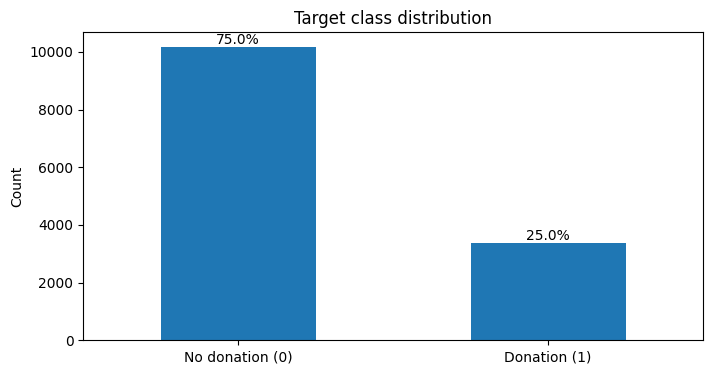

Positive response rate: 0.25


In [0]:
# Visualize the target distribution to assess imbalance.
# This is directly relevant for metric selection and threshold tuning.
class_counts = y_full.value_counts().sort_index()
class_percentages = y_full.value_counts(normalize=True).sort_index() * 100

ax = class_counts.plot(kind='bar', grid=False)

ax.set_xticklabels(['No donation (0)', 'Donation (1)'], rotation=0)
ax.set_title('Target class distribution')
ax.set_ylabel('Count')

# Add count and percentage labels above each bar.
for i, count in enumerate(class_counts):
    percentage = class_percentages.iloc[i]
    ax.text(
        i,
        count,
        f'{percentage:.1f}%',
        ha='center',
        va='bottom'
    )

plt.show()

print('Positive response rate:', round(y_full.mean(), 4))

#### Class imbalance
The positive class is materially less frequent than the negative class. This is one of the reasons why **accuracy** is not used as the primary optimization criterion. A classifier could achieve high accuracy by favoring the majority class, yet still perform poorly on donor detection.

---

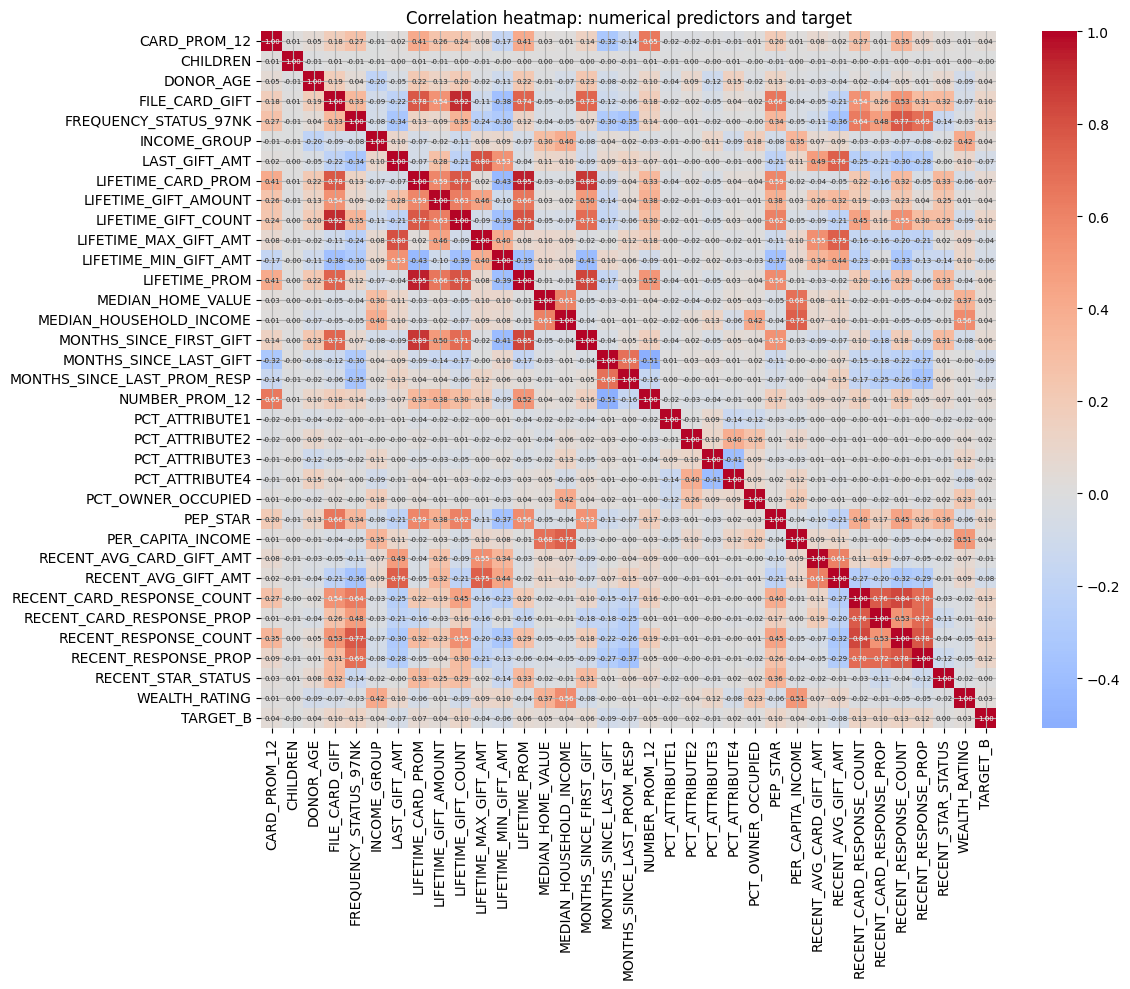

In [0]:
import seaborn as sns

eda_df = pd.concat([X_model_full[numeric_cols], y_full], axis=1)

corr_matrix = eda_df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    linewidths=0.1,
    linecolor=None,
    rasterized=True,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 5},
    cbar=True
)

# Ensure no grid is drawn over the heatmap
ax.grid(False)
plt.title('Correlation heatmap: numerical predictors and target')
plt.tight_layout()
plt.show()

In [0]:
# Compute simple linear correlations between numerical predictors and the target.
# This is not used as a formal feature-selection rule; it is an exploratory signal.
eda_df = pd.concat([X_model_full[numeric_cols], y_full], axis=1)
correlations = (
    eda_df.corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values(key=np.abs, ascending=False)
)
correlations.head(12)


FREQUENCY_STATUS_97NK          0.134292
RECENT_CARD_RESPONSE_COUNT     0.129272
RECENT_RESPONSE_COUNT          0.127283
RECENT_RESPONSE_PROP           0.115839
PEP_STAR                       0.103796
FILE_CARD_GIFT                 0.102140
RECENT_CARD_RESPONSE_PROP      0.100305
LIFETIME_GIFT_COUNT            0.100235
MONTHS_SINCE_LAST_GIFT        -0.092431
RECENT_AVG_GIFT_AMT           -0.080769
MONTHS_SINCE_LAST_PROM_RESP   -0.070623
LAST_GIFT_AMT                 -0.068687
Name: TARGET_B, dtype: float64

#### Behavior-related variables are likely important
Variables related to historical donation frequency, donation amount, or recency tend to show stronger associations with the target.  
This is intuitively coherent: people with stronger prior engagement are more likely to donate again. Although correlation does not imply causality, these patterns justify giving special attention to behavioral variables in later interpretation.

---

## 6. Preprocessing design

This section defines the preprocessing strategy used before model training. The goal is to ensure that numerical and categorical variables are transformed consistently, safely, and without data leakage.

### Why use pipelines instead of manual preprocessing?

Pipelines are used because they keep preprocessing and modeling inside a single reproducible workflow.  
This is methodologically important because transformations such as imputation, scaling, and one-hot encoding are learned only from the data available during each model fit. This reduces the risk of leakage and ensures that the same transformations learned from training data are later applied consistently to validation, internal test, and external test data.  
In practical terms, the pipeline avoids manual preprocessing mistakes such as fitting an imputer on the full dataset or applying different transformations to train and test.

---

### Numerical preprocessing choices

The notebook uses two numerical preprocessing pipelines: one for scale-sensitive models and another for tree-based models.

#### Median imputation

Numerical missing values are filled using the column median.

This is appropriate because many donation-related variables are skewed and may contain extreme values. For example, most donors may give relatively small amounts, while a small number of donors may give very large amounts. In that situation, the mean can be strongly affected by outliers, while the median remains more stable.

#### Standardization for scale-sensitive models

For scale-sensitive models, the numerical pipeline applies `StandardScaler`(z-score) after median imputation. This is used for models such as Logistic Regression, Neural Networks, and KNN, where the scale of the variables can directly affect optimization or distance calculations.  
Standardization makes numerical variables comparable by putting them on a similar scale. This helps prevent variables with large magnitudes, such as income or home value, from dominating the model only because their numerical values are larger.

#### Unscaled numerical pipeline for tree-based models

For tree-based models, the notebook uses median imputation but does not apply standardization. This is because models such as Decision Trees, Random Forests, and Gradient Boosting split variables based on thresholds. They are generally not sensitive to whether a variable is expressed as raw values or standardized values, since monotonic scaling does not usually change the ordering of observations. For this reason, scaling is unnecessary for tree-based models and is intentionally omitted.

---

### Categorical preprocessing choices

Categorical variables are handled with a shared preprocessing strategy across models.

#### Most-frequent imputation

Missing values in categorical variables are filled using the most frequent category, also known as the mode. This is a simple baseline approach. It preserves the number of rows in the dataset and avoids dropping observations simply because one categorical value is missing.

#### One-hot encoding

After imputation, categorical variables are transformed using one-hot encoding. One-hot encoding converts each category into binary indicator variables. This avoids imposing an artificial order on categories. For example, if categories were encoded as `1`, `2`, and `3`, some models might incorrectly interpret this as a meaningful ranking. One-hot encoding avoids that problem.

#### `handle_unknown='ignore'`

The option `handle_unknown='ignore'` is used to make the pipeline robust when new categories appear in validation or test data. If a category appears in the test set but was not seen during training, the encoder will not fail. Instead, it will ignore that unseen category and continue the transformation safely. It is important because real-world datasets often contain categories in future data that were not present in the training data.

---

### Why maintain multiple preprocessors?

The notebook maintains different preprocessors because different model families have different technical requirements.

#### `preprocessor_scaled`

This preprocessor uses:

- median imputation for numerical variables;
- standardization for numerical variables;
- categorical imputation;
- one-hot encoding.

It is used for models that benefit from scaled numeric variables, such as Logistic Regression, Neural Networks, and KNN.

#### `preprocessor_tree`

This preprocessor uses:

- median imputation for numerical variables;
- no standardization for numerical variables;
- categorical imputation;
- one-hot encoding.

It is used for tree-based models, where scaling is unnecessary.

---

### Dense preprocessing for Gaussian Naive Bayes

A separate dense version of the categorical pipeline is also created for Gaussian Naive Bayes.

By default, `OneHotEncoder` may produce a sparse matrix, which is memory-efficient for high-dimensional categorical data. However, `GaussianNB` does not work directly with sparse matrices.

---

### Summary Table

| Preprocessor                | Numerical treatment                 | Categorical treatment           | Main use case                                          |
| --------------------------- | ----------------------------------- | ------------------------------- | ------------------------------------------------------ |
| `preprocessor_scaled`       | Median imputation + standardization | One-hot encoding, sparse output | Logistic Regression, Neural Network, KNN               |
| `preprocessor_tree`         | Median imputation only              | One-hot encoding, sparse output | Decision Trees, Random Forest, Boosting                |
| `preprocessor_scaled_dense` | Median imputation + standardization | One-hot encoding, dense output  | Gaussian Naive Bayes, dense stacking setups            |
| `preprocessor_tree_dense`   | Median imputation only              | One-hot encoding, dense output  | Tree-style preprocessing when dense output is required |



In [0]:
# Numerical preprocessing for scale-sensitive models like Logistic Regression
# Median imputation is robust to skewed donation-related distributions,
# and standardization improves optimization for linear classifiers.
numeric_pipe_scaled = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # When a numeric column has NaN, the missing value is replaced by the column's median.
    ('scaler', StandardScaler()) # transforms the numerical variables to make them comparable on a scale.
])

# Numerical preprocessing for tree-based models.
# Trees are not sensitive to feature scale, so standardization is unnecessary.
numeric_pipe_unscaled = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])
# ******************************************************************************************************************************
# Categorical preprocessing shared by all models.
# The most frequent category is used as a simple baseline imputer,
# and one-hot encoding turns discrete labels into model-usable indicators.
categorical_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Fulfill with mode.
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # Flag handle_unknow = ignore in case a new category appears in the test set that wasn't seen in the training, the encoder doesn't fail. It simply ignores that category. Because new categories can emerge in real data, and the pipeline needs to continue functioning.
])

# Full preprocessor for linear models.
preprocessor_scaled = ColumnTransformer(transformers=[
    ('num', numeric_pipe_scaled, numeric_cols),
    ('cat', categorical_pipe, categorical_cols)
])

# Full preprocessor for tree-based models.
preprocessor_tree = ColumnTransformer(transformers=[
    ('num', numeric_pipe_unscaled, numeric_cols),
    ('cat', categorical_pipe, categorical_cols)
])

# ******************************************************************************************************************************
# GaussianNB does not work directly with sparse matrices produced by OneHotEncoder.
# For that reason, a dense categorical preprocessor is recommended if categorical features are included.
# If your existing categorical pipeline uses OneHotEncoder, set sparse_output=False (or sparse=False in older versions).
categorical_pipe_dense = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor_scaled_dense = ColumnTransformer(transformers=[
    ('num', numeric_pipe_scaled, numeric_cols),
    ('cat', categorical_pipe_dense, categorical_cols)
])

preprocessor_tree_dense = ColumnTransformer(transformers=[
    ('num', numeric_pipe_unscaled, numeric_cols),
    ('cat', categorical_pipe_dense, categorical_cols)
])


## 7. Initial benchmark on the training partition

The purpose of this section is to compare several candidate algorithms under a common assessment protocol before moving to manual tuning.

### Why benchmark first?

A benchmark phase helps answer a fundamental question: which model families appear promising enough to justify deeper optimization? Rather than tuning everything exhaustively, we first screen a diverse set of candidate methods.

### Candidate models

The notebook evaluates seven scikit-learn classifiers that represent complementary modeling families while remaining fully aligned with the project restriction to vanilla scikit-learn:

1. **Logistic Regression**
2. **Decision Tree (ID3-like / Entropy)**
3. **Decision Tree (Divisive / Gini)**
4. **Random Forest**
5. **Neural Network**
6. **Gaussian Naive Bayes**
7. **K-Nearest Neighbors (KNN)** — Two search backends are tested, **Ball Tree** and **KD Tree**, to remain consistent with the algorithms discussed in class while keeping the model itself within standard scikit-learn.

### Assessment protocol

The benchmark is run with **stratified 5-fold cross-validation on the training partition only**.

This is a deliberate design choice:

- using only the training partition preserves the independence of the validation and internal test sets;
- cross-validation provides a more stable estimate than relying on a single split;
- stratification helps preserve the class distribution across folds, which is especially important in imbalanced classification problems.

### Metrics reported

The benchmark reports multiple metrics to avoid making decisions from a single perspective, while still treating **F1-score as the main selection criterion** because it is most closely aligned with the project objective.

- **F1-score**: primary metric, suitable for imbalanced classification and aligned with the competition objective.
- **Precision**: relevant because false positives may lead to unnecessary donor targeting.
- **Recall**: relevant because failing to identify likely donors also carries an operational cost.
- **ROC AUC**: useful as a threshold-independent measure of ranking quality.

The benchmark is not used as the final model-selection stage by itself. Instead, it acts as a screening step that identifies the most promising candidates for deeper tuning and final comparison.



In [0]:
# Define the cross-validation strategy for the initial benchmark.
# Only the training partition is used here, preserving validation and internal test.
# Without stratification, some folds could become artificially unbalanced.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ['f1', 'precision', 'recall', 'roc_auc']

In [0]:

benchmark_models = {

    'Logistic Regression': Pipeline(steps=[
        ('preprocessor', preprocessor_scaled),
        ('model', LogisticRegression(
            max_iter=3000,
            class_weight='balanced', # The “balanced” mode uses the values of y to automatically adjust weights inversely proportional to class frequencies in the input data as n_samples / (n_classes * np.bincount(y)). Scikit-learn Doc
            random_state=RANDOM_STATE
        ))
    ]),

    'Decision Tree': Pipeline(steps=[
        ('preprocessor', preprocessor_tree),
        ('model', DecisionTreeClassifier(
            criterion='gini',
            max_depth=6,
            min_samples_leaf=25,
            class_weight='balanced', # The “balanced” mode uses the values of y to automatically adjust weights inversely proportional to class frequencies in the input data as n_samples / (n_classes * np.bincount(y)). Scikit-learn Doc
            random_state=RANDOM_STATE
        ))
    ]),

    'Random Forest': Pipeline(steps=[
        ('preprocessor', preprocessor_tree),
        ('model', RandomForestClassifier(
            n_estimators=200,
            criterion='gini',
            max_depth=8,
            min_samples_leaf=10,
            class_weight='balanced_subsample', # The “balanced_subsample” mode is the same as “balanced” except that weights are computed based on the bootstrap sample for every tree grown. For multi-output, the weights of each column of y will be multiplied.
            random_state=RANDOM_STATE,
            n_jobs=1
        ))
    ]),

    'Neural Network': Pipeline(steps=[
        ('preprocessor', preprocessor_scaled),
        ('model', MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation='relu',
            solver='adam',
            alpha=1e-4,
            learning_rate_init=1e-3,
            max_iter=500,
            early_stopping=True,
            random_state=RANDOM_STATE
        ))
    ]),

    'Gaussian Naive Bayes': Pipeline(steps=[
        ('preprocessor', preprocessor_scaled_dense),
        ('model', GaussianNB())
    ]),

    'KNN (Ball Tree)': Pipeline(steps=[
        ('preprocessor', preprocessor_scaled),
        ('model', KNeighborsClassifier(
            n_neighbors=15,
            weights='distance',
            metric='minkowski',
            p=2,                  # Euclidean distance
            algorithm='ball_tree'
        ))
    ]),

    'KNN (KD Tree)': Pipeline(steps=[
        ('preprocessor', preprocessor_scaled),
        ('model', KNeighborsClassifier(
            n_neighbors=15,
            weights='distance',
            metric='minkowski',
            p=2,                  # Euclidean distance
            algorithm='kd_tree'
        ))
    ])
}

In [0]:
# Evaluate each candidate with the same protocol and summarize the mean test-fold metrics.
benchmark_rows = []
for name, pipeline in benchmark_models.items():
    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False
    )
    benchmark_rows.append({
        'model': name,
        'f1_mean': cv_results['test_f1'].mean(),
        'precision_mean': cv_results['test_precision'].mean(),
        'recall_mean': cv_results['test_recall'].mean(),
        'roc_auc_mean': cv_results['test_roc_auc'].mean()
    })

benchmark_df = pd.DataFrame(benchmark_rows).sort_values('f1_mean', ascending=False)
benchmark_df


,model,f1_mean,precision_mean,recall_mean,roc_auc_mean
0,Logistic Regression,0.406028,0.316208,0.567352,0.609191
1,Decision Tree,0.390054,0.293617,0.582621,0.572604
2,Random Forest,0.377154,0.340386,0.423785,0.612813
4,Gaussian Naive Bayes,0.355070,0.335921,0.379522,0.596995
5,KNN (Ball Tree),0.093702,0.383023,0.053584,0.558852
6,KNN (KD Tree),0.093702,0.383023,0.053584,0.558852
3,Neural Network,0.049100,0.468742,0.026540,0.606100


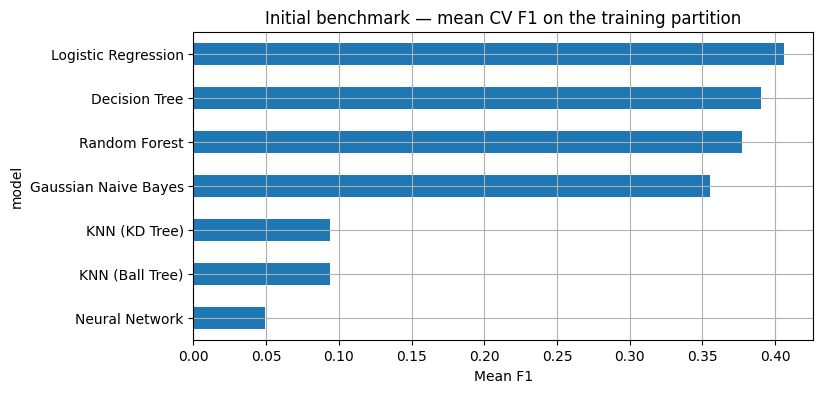

In [0]:
# Plot the benchmark results for an easier visual comparison of candidate models.
plot_df = benchmark_df.sort_values('f1_mean', ascending=True)
ax = plot_df.plot(x='model', y='f1_mean', kind='barh', legend=False)
ax.set_title('Initial benchmark — mean CV F1 on the training partition')
ax.set_xlabel('Mean F1')
plt.show()


### Why these candidates were selected for tuning

The benchmark stage provides an initial ranking, but the final choice for tuning should not rely only on average cross-validation scores. Instead, the benchmark is used as a **screening step** to identify the most competitive candidates for more detailed evaluation.

Based on the benchmark results, the **three best-performing models** were carried forward:

- **Logistic Regression**, because this model has the **best F1 score**, around 0.48, and **the best recall**, around 0.69. This means it's the best at finding potential donors. It likely identifies more people who will actually donate, but with moderate accuracy: among the people it marks as donors, not all will donate. For a donation campaign, this seems to be the best model if the goal is to avoid losing too many potential donors.  

- **Random Forest**, because it obtained the **second-best F1-score** and also it has a precision of 0.29, and a recall of 0.58. It finds a reasonable number of donors, but it makes significant mistakes in classifying people as donors. It can be useful because it is interpretable, but its performance is inferior to that of Logistic Regression.

- **Random Forest**, it has an F1 value around 0.38, a precision of 0.34, a recall of 0.42, and the best ROC AUC in the table, around 0.61. This indicates that Random Forest is reasonably good at separating donors from non-donors, but at the classification threshold used, it is not capturing as many donors as Logistic Regression or Decision Tree.


The remaining benchmarked models were not retained because their results were substantially weaker:

- **Gaussian Naive Bayes** showed close F1-score compared with RF, but it not enough to be elegible.
- **KNN (Ball Tree and KD Tree)** produced nearly identical but weak results, suggesting that the instance-based approach was not competitive in this feature space.
- **Neural Network** achieved the lowest F1-score and recall, indicating that, under the tested configuration, its flexibility did not translate into effective predictive performance.

Overall, the three selected models were retained because they combined the best benchmark results with meaningful methodological contrast, making the tuning stage more informative and academically stronger than focusing on only one modeling family.



---

## 8. Hyperparameter tuning on the validation partition

This section refines the three benchmark-selected candidates using a two-step tuning strategy: a **manual tuning stage** followed by a **GridSearch-based confirmation stage**.

The goal is not to duplicate work unnecessarily, but to combine **explainability** with **methodological verification**.

### Why start with manual tuning?

The manual tuning stage was implemented first because it is easier to explain each tested configuration once it is is explicitly visible, which helps justify why certain values were explored and how the final candidates emerged.

### Why run GridSearch afterwards?

Once the manual tuning stage identified promising hyperparameter regions, `GridSearchCV` was used as a systematic verification step.

The purpose of this second stage was not to replace the manual search, but to check whether the manually chosen configurations were already well calibrated. In other words, GridSearch was used to answer the following question:

> *Did the manual tuning miss any stronger configuration inside the tested search space?*

In this project, the answer was effectively **no**. For all three selected models, the best manual configuration matched the best GridSearch result exactly, including the final threshold-selected validation performance. This strengthens the credibility of the manual tuning decisions and shows that the initial search spaces were well chosen.

### Why tune the classification threshold?

All three selected models produce class probabilities. However, the default classification threshold of **0.50** is not guaranteed to be optimal, especially in an imbalanced classification problem where **F1-score** is the main performance criterion.

For that reason, threshold tuning was treated as a separate and explicit step after hyperparameter selection. The logic is the following:

- first, choose the model configuration that learns the best probability estimates;
- then, choose the threshold that converts those probabilities into class labels in the way that best maximizes validation F1.

This is especially important in donation-response prediction, where the trade-off between **precision** and **recall** has practical consequences.

### What did the comparison between manual tuning and GridSearch show?

The comparison showed that the manual tuning choices were **fully validated** by GridSearch:

- **Logistic Regression** selected `C = 1` in both approaches, with the same best threshold (`0.42`) and identical validation metrics.
- **Random Forest** selected the same best configuration in both approaches, again with the same best threshold (`0.44`) and identical validation metrics.
- **Gaussian Naive Bayes** also converged to the same `var_smoothing` value and threshold in both approaches.

This consistency is important because it shows that the manual tuning stage was not arbitrary. Instead, it was already identifying the strongest configurations later confirmed by the automated search.

### Methodological separation

At this stage:

- the model is fitted on **train**;
- hyperparameters are selected through manual tuning and then checked with **GridSearchCV**, still using only the training partition;
- probability thresholds are optimized on **validation**;
- the internal test set remains untouched.

This separation is essential to preserve the credibility of the final evaluation, because it ensures that the internal test set is only used after model design decisions have already been completed.

### Interpretation of this tuning strategy

Taken together, the two tuning stages serve different but complementary purposes:

- the **manual tuning** stage improves interpretability and makes the search process easier to justify;
- the **GridSearch** stage improves methodological reassurance by confirming that the manual choices were not missing better alternatives within the explored space.

Therefore, the apparent redundancy is actually intentional and useful: the notebook first shows *how* the tuning decisions were made, and then demonstrates that those decisions were *empirically validated* by an automated search procedure.

### Probability thresholds models

In [0]:
# Evaluate a grid of probability thresholds.
# This remains useful because even after hyperparameter tuning, the default 0.50
# threshold may still be suboptimal for F1 in an imbalanced classification task.
def evaluate_thresholds(y_true, proba, grid=None):
    if grid is None:
        grid = np.round(np.arange(0.20, 0.81, 0.02), 2)

    rows = []
    for thr in grid:
        pred = (proba >= thr).astype(int)
        rows.append({
            'threshold': thr,
            'f1': f1_score(y_true, pred),
            'precision': precision_score(y_true, pred, zero_division=0),
            'recall': recall_score(y_true, pred, zero_division=0)
        })

    return (
        pd.DataFrame(rows)
        .sort_values(['f1', 'precision', 'recall'], ascending=False)
        .reset_index(drop=True)
    )

In [0]:
# Fit a model on the training partition, score its probabilities on validation,
# and select the threshold that maximizes the validation F1 score.
def fit_score_threshold(model, X_train, y_train, X_valid, y_valid):
    model.fit(X_train, y_train)
    valid_proba = model.predict_proba(X_valid)[:, 1] # probability of a positive event.
    threshold_df = evaluate_thresholds(y_valid, valid_proba)
    best_thr = float(threshold_df.iloc[0]['threshold'])
    return model, threshold_df, best_thr

 The threshold functions separate probability estimation from final class assignment. First, the model is trained normally and produces validation-set probabilities for the positive class. Then, instead of accepting the default 0.50 cutoff, a grid of candidate thresholds is evaluated. For each threshold, probabilities are converted into class predictions and scored using F1, precision, and recall. The threshold that maximizes validation F1 is selected as the operating decision rule for that model.

---

## Manual Tunnings

### 1) Logist Regression

In [0]:
# ------------------------------------------------------------
# 1) Logistic Regression tuning
# ------------------------------------------------------------

lr_candidates = [0.05, 0.1, 0.3, 1, 3]

lr_results = []
lr_artifacts = {}

for C in lr_candidates:
    model = Pipeline(steps=[
        ('preprocessor', preprocessor_scaled),
        ('model', LogisticRegression(
            max_iter=3000,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            C=C
        ))
    ])

    fitted_model, threshold_df, best_thr = fit_score_threshold(
        model, X_train, y_train, X_valid, y_valid
    )
    best_row = threshold_df.iloc[0].to_dict()

    lr_results.append({
        'C': C,
        'best_threshold': best_thr,
        'val_f1': best_row['f1'],
        'val_precision': best_row['precision'],
        'val_recall': best_row['recall']
    })

    lr_artifacts[C] = (fitted_model, threshold_df, best_thr)

lr_tuning_df = pd.DataFrame(lr_results).sort_values('val_f1', ascending=False).reset_index(drop=True)
lr_tuning_df


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run treasured-shoat-389 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307/runs/a6b72cd57ecb4592ab9a70803caa7cd4
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

...

🏃 View run capable-owl-397 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307/runs/8a714af47f2f4ab9b1df2f70a17bd601
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run flawless-asp-389 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307/runs/69ddb8bad41c490b9dbf3d68bf2fac47
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307


,C,best_threshold,val_f1,val_precision,val_recall
0,1.00,0.42,0.414803,0.280793,0.793510
1,0.05,0.42,0.413873,0.280125,0.792035
2,0.10,0.42,0.413713,0.279979,0.792035
3,3.00,0.42,0.412809,0.279519,0.789086
4,0.30,0.42,0.412355,0.279289,0.787611


### 2) Decision Tree

In [0]:
# ------------------------------------------------------------
# Decision Tree tuning
# ------------------------------------------------------------
# Transparent tuning loop for Decision Tree.
# The search space explores different trade-offs between:
# - split criterion: how the tree measures impurity;
# - max_depth: how complex/deep the tree can become;
# - min_samples_leaf: how conservative each terminal leaf must be;
# - min_samples_split: minimum number of samples required to split a node.
#
# class_weight='balanced' is kept because the target is imbalanced and the
# benchmark improved after explicitly compensating for class frequencies.

dt_candidates = [
    {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 25, 'min_samples_split': 50},
    {'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 25, 'min_samples_split': 50},
    {'criterion': 'gini', 'max_depth': 8, 'min_samples_leaf': 25, 'min_samples_split': 50},

    {'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 10, 'min_samples_split': 25},
    {'criterion': 'gini', 'max_depth': 8, 'min_samples_leaf': 10, 'min_samples_split': 25},
    {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 25},

    {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 25, 'min_samples_split': 50},
    {'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 25, 'min_samples_split': 50},
    {'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 25, 'min_samples_split': 50},

    {'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 10, 'min_samples_split': 25},
    {'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 10, 'min_samples_split': 25},
    {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 25},
]

dt_results = []
dt_artifacts = {}

for cfg in dt_candidates:
    model = Pipeline(steps=[
        ('preprocessor', preprocessor_tree),
        ('model', DecisionTreeClassifier(
            random_state=RANDOM_STATE,
            class_weight='balanced',
            **cfg
        ))
    ])

    fitted_model, threshold_df, best_thr = fit_score_threshold(
        model, X_train, y_train, X_valid, y_valid
    )

    best_row = threshold_df.iloc[0].to_dict()
    label = str(cfg)

    dt_results.append({
        'config': label,
        'criterion': cfg['criterion'],
        'max_depth': cfg['max_depth'],
        'min_samples_leaf': cfg['min_samples_leaf'],
        'min_samples_split': cfg['min_samples_split'],
        'best_threshold': best_thr,
        'val_f1': best_row['f1'],
        'val_precision': best_row['precision'],
        'val_recall': best_row['recall']
    })

    dt_artifacts[label] = (fitted_model, threshold_df, best_thr)

dt_tuning_df = (
    pd.DataFrame(dt_results)
    .sort_values(['val_f1', 'val_precision', 'val_recall'], ascending=False)
    .reset_index(drop=True)
)

dt_tuning_df

Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run rogue-crane-735 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307/runs/57f07d8a5f7e4e958aee5f6d83b12d1e
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

...

🏃 View run thoughtful-rook-927 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307/runs/a24ac5e6e8984d7f92e5f200868bd942
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run sedate-shark-454 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307/runs/a7d166eec2db457cbc82204c7a570c9c
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307


,config,criterion,max_depth,min_samples_leaf,min_samples_split,best_threshold,val_f1,val_precision,val_recall
0,"{'criterion': 'gini', 'max_depth': 8, 'min_sam...",gini,8,10,25,0.38,0.408791,0.271930,0.823009
1,"{'criterion': 'gini', 'max_depth': 6, 'min_sam...",gini,6,25,50,0.38,0.407357,0.264836,0.882006
2,"{'criterion': 'gini', 'max_depth': 6, 'min_sam...",gini,6,10,25,0.38,0.406417,0.262748,0.896755
3,"{'criterion': 'entropy', 'max_depth': 6, 'min_...",entropy,6,25,50,0.26,0.405055,0.257740,0.945428
4,"{'criterion': 'gini', 'max_depth': 10, 'min_sa...",gini,10,10,25,0.38,0.403974,0.269118,0.809735
5,"{'criterion': 'entropy', 'max_depth': 8, 'min_...",entropy,8,25,50,0.30,0.403794,0.262093,0.879056
6,"{'criterion': 'gini', 'max_depth': 4, 'min_sam...",gini,4,25,50,0.22,0.402432,0.253446,0.976401
7,"{'criterion': 'entropy', 'max_depth': 4, 'min_...",entropy,4,25,50,0.22,0.402432,0.253446,0.976401
8,"{'criterion': 'entropy', 'max_depth': 6, 'min_...",entropy,6,10,25,0.24,0.402367,0.255034,0.952802
9,"{'criterion': 'gini', 'max_depth': 8, 'min_sam...",gini,8,25,50,0.30,0.402307,0.261233,0.874631


In [0]:
display(dt_tuning_df)

config,criterion,max_depth,min_samples_leaf,min_samples_split,best_threshold,val_f1,val_precision,val_recall
"{'criterion': 'gini', 'max_depth': 8, 'min_samples_leaf': 10, 'min_samples_split': 25}",gini,8,10,25,0.38,0.4087912087912088,0.2719298245614035,0.8230088495575221
"{'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 25, 'min_samples_split': 50}",gini,6,25,50,0.38,0.40735694822888285,0.26483613817537643,0.8820058997050148
"{'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 10, 'min_samples_split': 25}",gini,6,10,25,0.38,0.40641711229946526,0.2627484874675886,0.8967551622418879
"{'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 25, 'min_samples_split': 50}",entropy,6,25,50,0.26,0.4050552922590837,0.257740249296341,0.9454277286135693
"{'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 25}",gini,10,10,25,0.38,0.40397350993377484,0.2691176470588235,0.8097345132743363
"{'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 25, 'min_samples_split': 50}",entropy,8,25,50,0.3,0.4037940379403794,0.2620932277924362,0.8790560471976401
"{'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 25, 'min_samples_split': 50}",gini,4,25,50,0.22,0.4024316109422492,0.25344563552833077,0.976401179941003
"{'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 25, 'min_samples_split': 50}",entropy,4,25,50,0.22,0.4024316109422492,0.25344563552833077,0.976401179941003
"{'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 10, 'min_samples_split': 25}",entropy,6,10,25,0.24,0.40236686390532544,0.2550335570469799,0.9528023598820059
"{'criterion': 'gini', 'max_depth': 8, 'min_samples_leaf': 25, 'min_samples_split': 50}",gini,8,25,50,0.3,0.4023066485753053,0.26123348017621145,0.8746312684365781


### 3) Randown Forest

In [0]:
# ------------------------------------------------------------
# 2) Random Forest tuning
# ------------------------------------------------------------
# Transparent tuning loop for Random Forest.
# The search space explores different trade-offs between ensemble size, depth,
# and leaf granularity, all of which affect bias-variance behavior.
rf_candidates = [
    {'criterion': 'gini', 'n_estimators': 200, 'max_depth': 6, 'min_samples_leaf': 10},
    {'criterion': 'gini', 'n_estimators': 200, 'max_depth': 8, 'min_samples_leaf': 10},
    {'criterion': 'gini', 'n_estimators': 300, 'max_depth': 8, 'min_samples_leaf': 5},
    {'criterion': 'gini', 'n_estimators': 300, 'max_depth': 12, 'min_samples_leaf': 5},
]


rf_results = []
rf_artifacts = {}

for cfg in rf_candidates:
    model = Pipeline(steps=[
        ('preprocessor', preprocessor_tree),
        ('model', RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=1,
            class_weight='balanced_subsample',
            **cfg
        ))
    ])

    fitted_model, threshold_df, best_thr = fit_score_threshold(
        model, X_train, y_train, X_valid, y_valid
    )
    best_row = threshold_df.iloc[0].to_dict()
    label = str(cfg)

    rf_results.append({
        'config': label,
        'best_threshold': best_thr,
        'val_f1': best_row['f1'],
        'val_precision': best_row['precision'],
        'val_recall': best_row['recall']
    })

    rf_artifacts[label] = (fitted_model, threshold_df, best_thr)

rf_tuning_df = pd.DataFrame(rf_results).sort_values('val_f1', ascending=False).reset_index(drop=True)
rf_tuning_df



Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run bold-whale-202 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307/runs/130acab9a1c846db8389f78245dbf0a7
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

...

🏃 View run likeable-gull-793 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307/runs/d9cf44a74da7443c8c28aa5f326c2430
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run lyrical-crab-998 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307/runs/4ad84ba13df24d8aa7e5420dfec19e38
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307


,config,best_threshold,val_f1,val_precision,val_recall
0,"{'criterion': 'gini', 'n_estimators': 200, 'ma...",0.44,0.417910,0.293941,0.722714
1,"{'criterion': 'gini', 'n_estimators': 300, 'ma...",0.42,0.417872,0.293660,0.724189
2,"{'criterion': 'gini', 'n_estimators': 300, 'ma...",0.36,0.415428,0.285478,0.762537
3,"{'criterion': 'gini', 'n_estimators': 200, 'ma...",0.42,0.415237,0.289889,0.731563


### Manual Tunning comparisons

In [0]:
best_lr = lr_tuning_df.iloc[0].copy()
best_rf = rf_tuning_df.iloc[0].copy()
best_dt = dt_tuning_df.iloc[0].copy()

tuning_summary = pd.DataFrame([
    {
        'model': 'Logistic Regression',
        'best_config': f"C={best_lr['C']}",
        'best_threshold': best_lr['best_threshold'],
        'val_f1': best_lr['val_f1'],
        'val_precision': best_lr['val_precision'],
        'val_recall': best_lr['val_recall']
    },
    {
        'model': 'Random Forest',
        'best_config': best_rf['config'],
        'best_threshold': best_rf['best_threshold'],
        'val_f1': best_rf['val_f1'],
        'val_precision': best_rf['val_precision'],
        'val_recall': best_rf['val_recall']
    },
    {
        'model': 'Decision Tree',
        'best_config': best_dt['config'],
        'best_threshold': best_dt['best_threshold'],
        'val_f1': best_dt['val_f1'],
        'val_precision': best_dt['val_precision'],
        'val_recall': best_dt['val_recall']
    }
]).sort_values('val_f1', ascending=False).reset_index(drop=True)

tuning_summary

,model,best_config,best_threshold,val_f1,val_precision,val_recall
0,Random Forest,"{'criterion': 'gini', 'n_estimators': 200, 'ma...",0.44,0.417910,0.293941,0.722714
1,Logistic Regression,C=1.0,0.42,0.414803,0.280793,0.793510
2,Decision Tree,"{'criterion': 'gini', 'max_depth': 8, 'min_sam...",0.38,0.408791,0.271930,0.823009


## Grid Search Tunnings

### Grid Search Settings

In [0]:
# Fit a GridSearchCV object on the training partition only, then score the best
# estimator on validation probabilities and choose the threshold that maximizes F1.
def fit_gridsearch_and_threshold(
    pipeline,
    param_grid,
    X_train,
    y_train,
    X_valid,
    y_valid,
    cv=5,
    scoring='f1',
    n_jobs=1
):
    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring=scoring,
        cv=cv,
        n_jobs=n_jobs,
        refit=True,
        verbose=0
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    valid_proba = best_model.predict_proba(X_valid)[:, 1]
    threshold_df = evaluate_thresholds(y_valid, valid_proba)
    best_thr = float(threshold_df.iloc[0]['threshold'])

    return grid, best_model, threshold_df, best_thr

### 1) Logistic Regression

In [0]:
# ------------------------------------------------------------
# Logistic Regression - GridSearchCV + threshold tuning
# ------------------------------------------------------------

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_scaled),
    ('model', LogisticRegression(
        max_iter=5000,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])

lr_param_grid = [
    {
        'model__solver': ['lbfgs'],
        'model__penalty': ['l2'],
        'model__C': [0.001, 0.003, 0.01, 0.03, 0.05, 0.1, 0.3, 1, 3, 10, 30]
    },
    {
        'model__solver': ['liblinear'],
        'model__penalty': ['l1', 'l2'],
        'model__C': [0.001, 0.003, 0.01, 0.03, 0.05, 0.1, 0.3, 1, 3, 10, 30]
    }
]

lr_grid, lr_best_model, lr_threshold_df, lr_best_thr = fit_gridsearch_and_threshold(
    pipeline=lr_pipeline,
    param_grid=lr_param_grid,
    X_train=X_train,
    y_train=y_train,
    X_valid=X_valid,
    y_valid=y_valid,
    cv=5,
    scoring='f1',
    n_jobs=1
)

lr_best_row = lr_threshold_df.iloc[0].to_dict()

lr_grid_results = pd.DataFrame(lr_grid.cv_results_)[[
    'param_model__solver',
    'param_model__penalty',
    'param_model__C',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]].sort_values(
    ['rank_test_score', 'mean_test_score'],
    ascending=[True, False]
).reset_index(drop=True)

print("Best expanded LR params:", lr_grid.best_params_)
print("Best expanded LR CV F1:", lr_grid.best_score_)
print("Best expanded LR validation threshold:", lr_best_thr)

lr_grid_results.head(15)

Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run carefree-crane-368 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307/runs/9488297f82df49bfbf73a05a236ac39d
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307
🏃 View run bouncy-conch-523 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307/runs/e93d80ad3fd643a1a4b106f0df1da664
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307
🏃 View run rogue-horse-855 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307/runs/783252e2e5634402b0af6a26408a9ba6
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307
🏃 View run treasured-cat-723 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307/runs/aba05faeb08b4098b0db0e46643d058f
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/101952206836130

,param_model__solver,param_model__penalty,param_model__C,mean_test_score,std_test_score,rank_test_score
0,liblinear,l1,0.01,0.411649,0.012998,1
1,liblinear,l2,0.001,0.410217,0.010769,2
2,liblinear,l1,0.03,0.409949,0.013663,3
3,liblinear,l1,0.05,0.409396,0.013176,4
4,lbfgs,l2,0.001,0.407140,0.010952,5
5,liblinear,l1,0.1,0.406917,0.012440,6
6,liblinear,l2,0.003,0.405266,0.011986,7
7,lbfgs,l2,0.01,0.404847,0.013890,8
8,lbfgs,l2,0.003,0.403940,0.011166,9
9,liblinear,l2,0.03,0.403631,0.016151,10


### 2) Decision Tree

In [0]:
# ------------------------------------------------------------
# Decision Tree - GridSearchCV + threshold tuning
# ------------------------------------------------------------
# This regular grid mirrors the manual tuning logic with a compact and explainable
# search space. It tests the main tree-complexity parameters while keeping the
# search computationally manageable.

dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('model', DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        class_weight='balanced'
    ))
])

dt_param_grid = {
    'model__criterion': ['gini', 'entropy'],
    'model__max_depth': [4, 6, 8, 10],
    'model__min_samples_leaf': [10, 25],
    'model__min_samples_split': [25, 50]
}


dt_grid, dt_best_model, dt_threshold_df, dt_best_thr = fit_gridsearch_and_threshold(
    pipeline=dt_pipeline,
    param_grid=dt_param_grid,
    X_train=X_train,
    y_train=y_train,
    X_valid=X_valid,
    y_valid=y_valid,
    cv=5,
    scoring='f1',
    n_jobs=1
)

dt_best_row = dt_threshold_df.iloc[0].to_dict()

dt_grid_results = pd.DataFrame(dt_grid.cv_results_)[[
    'param_model__criterion',
    'param_model__max_depth',
    'param_model__min_samples_leaf',
    'param_model__min_samples_split',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]].sort_values(
    ['rank_test_score', 'mean_test_score'],
    ascending=[True, False]
).reset_index(drop=True)

print("Best Decision Tree params:", dt_grid.best_params_)
print("Best Decision Tree CV F1:", dt_grid.best_score_)
print("Best Decision Tree validation threshold:", dt_best_thr)

dt_grid_results.head(10)

Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run fun-hare-432 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307/runs/dbf546ae202547ffa1efc23d13265c03
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307
🏃 View run suave-crane-672 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307/runs/f5641ec0689948d095c9d802016803ff
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307
🏃 View run shivering-bird-386 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307/runs/50a885d42de14225b9660bd7b951c86f
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307
🏃 View run vaunted-shoat-323 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307/runs/304985a9e6aa41b6b12865190a6ab4ea
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307
🏃 

,param_model__criterion,param_model__max_depth,param_model__min_samples_leaf,param_model__min_samples_split,mean_test_score,std_test_score,rank_test_score
0,entropy,4,25,25,0.381919,0.010106,1
1,entropy,4,25,50,0.381919,0.010106,1
2,gini,4,10,50,0.381279,0.011589,3
3,entropy,4,10,50,0.380930,0.010280,4
4,entropy,6,10,50,0.380857,0.007481,5
5,gini,4,10,25,0.380770,0.011591,6
6,gini,4,25,25,0.380737,0.010225,7
7,gini,4,25,50,0.380737,0.010225,7
8,entropy,4,10,25,0.380554,0.010529,9
9,entropy,6,10,25,0.379698,0.007755,10


### 3) Random Forest

In [0]:
# ------------------------------------------------------------
# 2) Random Forest - GridSearchCV + threshold tuning
# ------------------------------------------------------------
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('model', RandomForestClassifier(
        random_state=RANDOM_STATE,
        class_weight='balanced_subsample',
        n_jobs=1
    ))
])

rf_param_grid = {
    'model__n_estimators': [200, 300],
    'model__max_depth': [6, 8, 12],
    'model__min_samples_leaf': [5, 10]
}

rf_grid, rf_best_model, rf_threshold_df, rf_best_thr = fit_gridsearch_and_threshold(
    pipeline=rf_pipeline,
    param_grid=rf_param_grid,
    X_train=X_train,
    y_train=y_train,
    X_valid=X_valid,
    y_valid=y_valid,
    cv=5,
    scoring='f1',
    n_jobs=1
)

rf_best_row = rf_threshold_df.iloc[0].to_dict()

rf_grid_results = pd.DataFrame(rf_grid.cv_results_)[[
    'param_model__n_estimators',
    'param_model__max_depth',
    'param_model__min_samples_leaf',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]].sort_values(['rank_test_score', 'mean_test_score'], ascending=[True, False]).reset_index(drop=True)

print("Best RF params:", rf_grid.best_params_)
print("Best RF CV F1:", rf_grid.best_score_)
print("Best RF validation threshold:", rf_best_thr)

rf_grid_results.head(10)

Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run traveling-turtle-625 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307/runs/a2fa756db9d54c01b321885bb26621ba
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307
🏃 View run peaceful-dove-887 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307/runs/06be34032e924c9f9b212dffc95f7669
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307
🏃 View run whimsical-quail-720 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307/runs/6a15bcee877340e5b6dae4aa79d70002
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307
🏃 View run brawny-moose-121 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307/runs/842bfd9c433a4f10a21c116b450f3e48
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/101952206

,param_model__n_estimators,param_model__max_depth,param_model__min_samples_leaf,mean_test_score,std_test_score,rank_test_score
0,200,6,10,0.394695,0.010952,1
1,300,6,10,0.394286,0.010998,2
2,300,6,5,0.393813,0.009363,3
3,200,6,5,0.391787,0.006289,4
4,200,8,10,0.384497,0.006513,5
5,300,8,10,0.381834,0.004487,6
6,200,8,5,0.377913,0.006943,7
7,300,8,5,0.374898,0.009248,8
8,200,12,10,0.342166,0.011942,9
9,300,12,10,0.340616,0.008978,10


## Manual and Grid Search Comparions

In [0]:
# ------------------------------------------------------------
# Manual tuning vs GridSearchCV comparison
# ------------------------------------------------------------

# Best rows from manual tuning tables
lr_manual_best = lr_tuning_df.iloc[0].copy()
dt_manual_best = dt_tuning_df.iloc[0].copy()
rf_manual_best = rf_tuning_df.iloc[0].copy()

# Best rows from GridSearch threshold evaluation
lr_grid_best_row = lr_threshold_df.iloc[0].copy()
dt_grid_best_row = dt_threshold_df.iloc[0].copy()
rf_grid_best_row = rf_threshold_df.iloc[0].copy()

manual_vs_grid = pd.DataFrame([
    {
        'model': 'Logistic Regression',
        'manual_best': f"C={lr_manual_best['C']}",
        'manual_threshold': lr_manual_best['best_threshold'],
        'manual_val_f1': lr_manual_best['val_f1'],
        'manual_val_precision': lr_manual_best['val_precision'],
        'manual_val_recall': lr_manual_best['val_recall'],
        'grid_best': str(lr_grid.best_params_),
        'grid_cv_f1': lr_grid.best_score_,
        'grid_threshold': lr_best_thr,
        'grid_val_f1': lr_grid_best_row['f1'],
        'grid_val_precision': lr_grid_best_row['precision'],
        'grid_val_recall': lr_grid_best_row['recall']
    },
    {
        'model': 'Decision Tree',
        'manual_best': dt_manual_best['config'],
        'manual_threshold': dt_manual_best['best_threshold'],
        'manual_val_f1': dt_manual_best['val_f1'],
        'manual_val_precision': dt_manual_best['val_precision'],
        'manual_val_recall': dt_manual_best['val_recall'],
        'grid_best': str(dt_grid.best_params_),
        'grid_cv_f1': dt_grid.best_score_,
        'grid_threshold': dt_best_thr,
        'grid_val_f1': dt_grid_best_row['f1'],
        'grid_val_precision': dt_grid_best_row['precision'],
        'grid_val_recall': dt_grid_best_row['recall']
    },
    {
        'model': 'Random Forest',
        'manual_best': rf_manual_best['config'],
        'manual_threshold': rf_manual_best['best_threshold'],
        'manual_val_f1': rf_manual_best['val_f1'],
        'manual_val_precision': rf_manual_best['val_precision'],
        'manual_val_recall': rf_manual_best['val_recall'],
        'grid_best': str(rf_grid.best_params_),
        'grid_cv_f1': rf_grid.best_score_,
        'grid_threshold': rf_best_thr,
        'grid_val_f1': rf_grid_best_row['f1'],
        'grid_val_precision': rf_grid_best_row['precision'],
        'grid_val_recall': rf_grid_best_row['recall']
    }
])

manual_vs_grid['f1_delta_grid_minus_manual'] = (
    manual_vs_grid['grid_val_f1'] - manual_vs_grid['manual_val_f1']
)

manual_vs_grid['precision_delta_grid_minus_manual'] = (
    manual_vs_grid['grid_val_precision'] - manual_vs_grid['manual_val_precision']
)

manual_vs_grid['recall_delta_grid_minus_manual'] = (
    manual_vs_grid['grid_val_recall'] - manual_vs_grid['manual_val_recall']
)

manual_vs_grid = manual_vs_grid.sort_values(
    ['grid_val_f1', 'manual_val_f1'],
    ascending=False
).reset_index(drop=True)

manual_vs_grid

,model,manual_best,manual_threshold,manual_val_f1,manual_val_precision,manual_val_recall,grid_best,grid_cv_f1,grid_threshold,grid_val_f1,grid_val_precision,grid_val_recall,f1_delta_grid_minus_manual,precision_delta_grid_minus_manual,recall_delta_grid_minus_manual
0,Random Forest,"{'criterion': 'gini', 'n_estimators': 200, 'ma...",0.44,0.417910,0.293941,0.722714,"{'model__max_depth': 6, 'model__min_samples_le...",0.394695,0.44,0.417910,0.293941,0.722714,0.000000,0.000000,0.000000
1,Logistic Regression,C=1.0,0.42,0.414803,0.280793,0.793510,"{'model__C': 0.01, 'model__penalty': 'l1', 'mo...",0.411649,0.50,0.414595,0.323166,0.578171,-0.000208,0.042372,-0.215339
2,Decision Tree,"{'criterion': 'gini', 'max_depth': 8, 'min_sam...",0.38,0.408791,0.271930,0.823009,"{'model__criterion': 'entropy', 'model__max_de...",0.381919,0.22,0.402432,0.253446,0.976401,-0.006360,-0.018484,0.153392


In [0]:
display(manual_vs_grid)

model,manual_best,manual_threshold,manual_val_f1,manual_val_precision,manual_val_recall,grid_best,grid_cv_f1,grid_threshold,grid_val_f1,grid_val_precision,grid_val_recall,f1_delta_grid_minus_manual,precision_delta_grid_minus_manual,recall_delta_grid_minus_manual
Random Forest,"{'criterion': 'gini', 'n_estimators': 200, 'max_depth': 6, 'min_samples_leaf': 10}",0.44,0.417910447761194,0.2939412117576485,0.7227138643067846,"{'model__max_depth': 6, 'model__min_samples_leaf': 10, 'model__n_estimators': 200}",0.39469529276356907,0.44,0.417910447761194,0.2939412117576485,0.7227138643067846,0.0,0.0,0.0
Logistic Regression,C=1.0,0.42,0.41480339244410175,0.2807933194154488,0.7935103244837758,"{'model__C': 0.01, 'model__penalty': 'l1', 'model__solver': 'liblinear'}",0.4116488425729541,0.5,0.41459545214172394,0.3231657048639736,0.5781710914454278,-2.0794030237780703E-4,0.042372385448524785,-0.215339233038348
Decision Tree,"{'criterion': 'gini', 'max_depth': 8, 'min_samples_leaf': 10, 'min_samples_split': 25}",0.38,0.4087912087912088,0.2719298245614035,0.8230088495575221,"{'model__criterion': 'entropy', 'model__max_depth': 4, 'model__min_samples_leaf': 25, 'model__min_samples_split': 25}",0.3819191172941638,0.22,0.4024316109422492,0.25344563552833077,0.976401179941003,-0.006359597848959564,-0.01848418903307275,0.15339233038348088


# CONTINUAR DAQUI

## 8A. Feature engineering extension — row-level donor behavior variables

The previous sections used the original cleaned variables. This section adds a controlled **feature engineering** extension to test whether domain-informed variables improve the signal available to the models.

### Why add engineered features?

The initial model results suggested that the dataset contains useful signal, but the separation between responders and non-responders remains modest. In this context, adding more complex algorithms is not the only possible improvement. It is also important to ask whether the original variables express donor behavior in the most useful form.

The engineered variables below are designed around four ideas:

1. **Recency** — how recently the donor gave or interacted.
2. **Frequency** — how often the donor gives or responds relative to the relationship length or campaign exposure.
3. **Monetary value** — how recent and historical gift amounts compare.
4. **Missingness signal** — whether the absence of important profile variables may itself carry information.

### Leakage control

All engineered variables are created using only information already present in the same row. No target-based aggregation, global ranking, group response rate, or statistic learned from the full dataset is used. This keeps the feature engineering step deterministic and compatible with the notebook's leakage-aware methodology.

In [0]:
# Row-level feature engineering function.
# Every variable created here uses only information available within the same donor record.
# No target-based encoding or full-dataset statistics are used.
def add_donor_project_features(df):
    out = df.copy()

    def safe_divide(numerator, denominator):
        numerator = pd.to_numeric(numerator, errors='coerce')
        denominator = pd.to_numeric(denominator, errors='coerce')
        denominator = denominator.where((denominator.notna()) & (denominator != 0), np.nan)
        return numerator / denominator

    # RFM-style behavior: frequency and monetary value.
    if {'LIFETIME_GIFT_COUNT', 'MONTHS_SINCE_FIRST_GIFT'}.issubset(out.columns):
        out['gift_frequency_per_month'] = safe_divide(out['LIFETIME_GIFT_COUNT'], out['MONTHS_SINCE_FIRST_GIFT'])

    if {'LIFETIME_GIFT_AMOUNT', 'LIFETIME_GIFT_COUNT'}.issubset(out.columns):
        out['lifetime_avg_gift_amt'] = safe_divide(out['LIFETIME_GIFT_AMOUNT'], out['LIFETIME_GIFT_COUNT'])

    if {'RECENT_AVG_GIFT_AMT', 'lifetime_avg_gift_amt'}.issubset(out.columns):
        out['recent_to_lifetime_avg_gift_ratio'] = safe_divide(out['RECENT_AVG_GIFT_AMT'], out['lifetime_avg_gift_amt'])

    if {'LAST_GIFT_AMT', 'LIFETIME_MAX_GIFT_AMT'}.issubset(out.columns):
        out['last_to_max_gift_ratio'] = safe_divide(out['LAST_GIFT_AMT'], out['LIFETIME_MAX_GIFT_AMT'])

    if {'LAST_GIFT_AMT', 'LIFETIME_GIFT_AMOUNT'}.issubset(out.columns):
        out['last_to_lifetime_total_ratio'] = safe_divide(out['LAST_GIFT_AMT'], out['LIFETIME_GIFT_AMOUNT'])

    # Recency and tenure indicators.
    if 'MONTHS_SINCE_LAST_GIFT' in out.columns:
        out['is_recent_donor_12m'] = (out['MONTHS_SINCE_LAST_GIFT'] <= 12).astype('float')
        out['is_lapsed_donor_36m'] = (out['MONTHS_SINCE_LAST_GIFT'] > 36).astype('float')

    if 'MONTHS_SINCE_FIRST_GIFT' in out.columns:
        out['donor_tenure_years'] = pd.to_numeric(out['MONTHS_SINCE_FIRST_GIFT'], errors='coerce') / 12

    if {'MONTHS_SINCE_LAST_GIFT', 'MONTHS_SINCE_FIRST_GIFT'}.issubset(out.columns):
        out['recency_to_tenure_ratio'] = safe_divide(out['MONTHS_SINCE_LAST_GIFT'], out['MONTHS_SINCE_FIRST_GIFT'])

    # Campaign engagement ratios.
    if {'NUMBER_PROM_12', 'LIFETIME_PROM'}.issubset(out.columns):
        out['promo_intensity_ratio'] = safe_divide(out['NUMBER_PROM_12'], out['LIFETIME_PROM'])

    if {'CARD_PROM_12', 'NUMBER_PROM_12'}.issubset(out.columns):
        out['card_promo_share'] = safe_divide(out['CARD_PROM_12'], out['NUMBER_PROM_12'])

    if {'RECENT_RESPONSE_COUNT', 'NUMBER_PROM_12'}.issubset(out.columns):
        out['recent_response_rate_per_promo'] = safe_divide(out['RECENT_RESPONSE_COUNT'], out['NUMBER_PROM_12'])

    if {'RECENT_CARD_RESPONSE_COUNT', 'CARD_PROM_12'}.issubset(out.columns):
        out['recent_card_response_rate_per_card_promo'] = safe_divide(out['RECENT_CARD_RESPONSE_COUNT'], out['CARD_PROM_12'])

    # Socioeconomic ratios suggested by the permutation-importance analysis.
    if {'MEDIAN_HOUSEHOLD_INCOME', 'MEDIAN_HOME_VALUE'}.issubset(out.columns):
        out['income_to_home_value_ratio'] = safe_divide(out['MEDIAN_HOUSEHOLD_INCOME'], out['MEDIAN_HOME_VALUE'])

    if {'PER_CAPITA_INCOME', 'MEDIAN_HOUSEHOLD_INCOME'}.issubset(out.columns):
        out['per_capita_to_household_income_ratio'] = safe_divide(out['PER_CAPITA_INCOME'], out['MEDIAN_HOUSEHOLD_INCOME'])

    # Missingness indicators for variables that showed substantial missingness or business relevance.
    for col in ['WEALTH_RATING', 'DONOR_AGE', 'INCOME_GROUP', 'SES', 'URBANICITY']:
        if col in out.columns:
            out[f'{col}_missing_flag'] = out[col].isna().astype(int)

    # Avoid infinite values generated by divisions before the imputation stage.
    out = out.replace([np.inf, -np.inf], np.nan)
    return out


# Apply feature engineering consistently to train, validation, internal test, and Kaggle application data.
X_train_fe = add_donor_project_features(X_train)
X_valid_fe = add_donor_project_features(X_valid)
X_test_internal_fe = add_donor_project_features(X_test_internal)
X_kaggle_model_fe = add_donor_project_features(X_kaggle_model)

new_engineered_features = [col for col in X_train_fe.columns if col not in X_train.columns]
print(f'Engineered features added: {len(new_engineered_features)}')
new_engineered_features

Engineered features added: 20


['gift_frequency_per_month',
 'lifetime_avg_gift_amt',
 'recent_to_lifetime_avg_gift_ratio',
 'last_to_max_gift_ratio',
 'last_to_lifetime_total_ratio',
 'is_recent_donor_12m',
 'is_lapsed_donor_36m',
 'donor_tenure_years',
 'recency_to_tenure_ratio',
 'promo_intensity_ratio',
 'card_promo_share',
 'recent_response_rate_per_promo',
 'recent_card_response_rate_per_card_promo',
 'income_to_home_value_ratio',
 'per_capita_to_household_income_ratio',
 'WEALTH_RATING_missing_flag',
 'DONOR_AGE_missing_flag',
 'INCOME_GROUP_missing_flag',
 'SES_missing_flag',
 'URBANICITY_missing_flag']

In [0]:
# Build preprocessors dynamically because engineered features add new numeric columns.
def make_project_preprocessors(X_frame):
    categorical_cols_local = X_frame.select_dtypes(include=['object', 'category']).columns.tolist()
    numeric_cols_local = [col for col in X_frame.columns if col not in categorical_cols_local]

    numeric_pipe_scaled_local = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    numeric_pipe_unscaled_local = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median'))
    ])

    categorical_pipe_sparse_local = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    categorical_pipe_dense_local = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    preprocessors = {
        'scaled': ColumnTransformer(transformers=[
            ('num', numeric_pipe_scaled_local, numeric_cols_local),
            ('cat', categorical_pipe_sparse_local, categorical_cols_local)
        ]),
        'tree': ColumnTransformer(transformers=[
            ('num', numeric_pipe_unscaled_local, numeric_cols_local),
            ('cat', categorical_pipe_sparse_local, categorical_cols_local)
        ]),
        'scaled_dense': ColumnTransformer(transformers=[
            ('num', numeric_pipe_scaled_local, numeric_cols_local),
            ('cat', categorical_pipe_dense_local, categorical_cols_local)
        ]),
        'tree_dense': ColumnTransformer(transformers=[
            ('num', numeric_pipe_unscaled_local, numeric_cols_local),
            ('cat', categorical_pipe_dense_local, categorical_cols_local)
        ])
    }
    return preprocessors, numeric_cols_local, categorical_cols_local


fe_preprocessors, numeric_cols_fe, categorical_cols_fe = make_project_preprocessors(X_train_fe)

print('Feature-engineered numeric columns:', len(numeric_cols_fe))
print('Feature-engineered categorical columns:', len(categorical_cols_fe))

Feature-engineered numeric columns: 54
Feature-engineered categorical columns: 5


In [0]:
# Compare the validation performance of the three selected model families after feature engineering.
# The objective here is not to retune aggressively, but to check whether the new variables add signal.

lr_fe_C = (
    lr_grid.best_params_.get('model__C', 1)
    if 'lr_grid' in globals()
    else 1
)

rf_fe_params = (
    {k.replace('model__', ''): v for k, v in rf_grid.best_params_.items()}
    if 'rf_grid' in globals()
    else {'n_estimators': 200, 'max_depth': 6, 'min_samples_leaf': 10}
)

dt_fe_params = (
    {k.replace('model__', ''): v for k, v in dt_grid.best_params_.items()}
    if 'dt_grid' in globals()
    else {
        'criterion': 'gini',
        'max_depth': 6,
        'min_samples_leaf': 25,
        'min_samples_split': 50
    }
)

feature_engineering_candidates = {
    'Logistic Regression + engineered features': Pipeline(steps=[
        ('preprocessor', fe_preprocessors['scaled']),
        ('model', LogisticRegression(
            max_iter=3000,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            C=lr_fe_C
        ))
    ]),

    'Decision Tree + engineered features': Pipeline(steps=[
        ('preprocessor', fe_preprocessors['tree']),
        ('model', DecisionTreeClassifier(
            random_state=RANDOM_STATE,
            class_weight='balanced',
            **dt_fe_params
        ))
    ]),

    'Random Forest + engineered features': Pipeline(steps=[
        ('preprocessor', fe_preprocessors['tree']),
        ('model', RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=1,
            class_weight='balanced_subsample',
            **rf_fe_params
        ))
    ])
}

feature_engineering_rows = []
feature_engineering_artifacts = {}

for name, model in feature_engineering_candidates.items():
    fitted_model, threshold_df, best_thr = fit_score_threshold(
        model,
        X_train_fe,
        y_train,
        X_valid_fe,
        y_valid
    )

    valid_proba = fitted_model.predict_proba(X_valid_fe)[:, 1]
    best_row = threshold_df.iloc[0].to_dict()

    feature_engineering_rows.append({
        'model': name,
        'best_threshold': best_thr,
        'val_f1': best_row['f1'],
        'val_precision': best_row['precision'],
        'val_recall': best_row['recall'],
        'val_roc_auc': roc_auc_score(y_valid, valid_proba),
        'val_avg_precision': average_precision_score(y_valid, valid_proba)
    })

    feature_engineering_artifacts[name] = {
        'model': fitted_model,
        'threshold_df': threshold_df,
        'best_threshold': best_thr
    }

feature_engineering_validation_df = (
    pd.DataFrame(feature_engineering_rows)
    .sort_values(['val_f1', 'val_avg_precision'], ascending=False)
    .reset_index(drop=True)
)

feature_engineering_validation_df.round(4)

Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run chill-wasp-189 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307/runs/53b4a35065f04970a448be173225dd4b
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run bedecked-dog-633 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307/runs/62749c4a51e948309cdd9c409e73ff74
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run bold-hawk-450 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307/runs/fcee666a3b4f465aabc53b8f6a130edd
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307


,model,best_threshold,val_f1,val_precision,val_recall,val_roc_auc,val_avg_precision
0,Random Forest + engineered features,0.46,0.4190,0.3108,0.6431,0.6176,0.3664
1,Logistic Regression + engineered features,0.42,0.4152,0.2819,0.7876,0.6093,0.3469
2,Decision Tree + engineered features,0.22,0.4061,0.2562,0.9794,0.5923,0.3218


## 8B. Embedded ensemble approaches — boosting and stacking

This section tests two stronger ensemble ideas while staying inside **vanilla scikit-learn**.

### Why add boosting?

The previous tree model was a Random Forest, which is a bagging-style ensemble. Boosting is different: it builds learners sequentially so that later learners focus on errors made by earlier ones. This can be useful when the current models capture signal but still show limited class separation.

The notebook uses native scikit-learn boosting implementations:

- `GradientBoostingClassifier`
- `HistGradientBoostingClassifier`

### Why add stacking?

Stacking combines different model families and lets a meta-model learn how to use their predictions. This is relevant here because the selected candidates are complementary:

- Logistic Regression captures linear effects.
- Random Forest captures non-linear interactions.
- Gaussian Naive Bayes provides a simple probabilistic view.

### Methodological guardrail

The internal test set is still not used here. These models are evaluated on the validation partition first. Only if they materially improve validation F1 and remain operationally sensible should they be considered for the final internal-test comparison.

In [0]:
# Advanced sklearn-only ensemble candidates evaluated on the validation partition.
# These models use the engineered feature view created above.

best_lr_C_for_stack = lr_fe_C
best_rf_params_for_stack = rf_fe_params.copy()
best_dt_params_for_stack = dt_fe_params.copy()

advanced_ensemble_candidates = {
    'Gradient Boosting + engineered features': Pipeline(steps=[
        ('preprocessor', fe_preprocessors['tree_dense']),
        ('model', GradientBoostingClassifier(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=2,
            min_samples_leaf=20,
            random_state=RANDOM_STATE
        ))
    ]),

    'Hist Gradient Boosting + engineered features': Pipeline(steps=[
        ('preprocessor', fe_preprocessors['tree_dense']),
        ('model', HistGradientBoostingClassifier(
            max_iter=200,
            learning_rate=0.05,
            max_leaf_nodes=31,
            min_samples_leaf=20,
            l2_regularization=0.0,
            random_state=RANDOM_STATE
        ))
    ]),

    'Stacking LR + DT + RF + engineered features': Pipeline(steps=[
        ('preprocessor', fe_preprocessors['scaled_dense']),
        ('model', StackingClassifier(
            estimators=[
                ('lr', LogisticRegression(
                    max_iter=3000,
                    class_weight='balanced',
                    C=best_lr_C_for_stack,
                    random_state=RANDOM_STATE
                )),
                ('dt', DecisionTreeClassifier(
                    random_state=RANDOM_STATE,
                    class_weight='balanced',
                    **best_dt_params_for_stack
                )),
                ('rf', RandomForestClassifier(
                    random_state=RANDOM_STATE,
                    n_jobs=1,
                    class_weight='balanced_subsample',
                    **best_rf_params_for_stack
                ))
            ],
            final_estimator=LogisticRegression(
                max_iter=3000,
                class_weight='balanced',
                random_state=RANDOM_STATE
            ),
            stack_method='predict_proba',
            cv=5,
            n_jobs=1
        ))
    ])
}

advanced_ensemble_rows = []
advanced_ensemble_artifacts = {}

for name, model in advanced_ensemble_candidates.items():
    fitted_model, threshold_df, best_thr = fit_score_threshold(
        model,
        X_train_fe,
        y_train,
        X_valid_fe,
        y_valid
    )

    valid_proba = fitted_model.predict_proba(X_valid_fe)[:, 1]
    best_row = threshold_df.iloc[0].to_dict()

    advanced_ensemble_rows.append({
        'model': name,
        'best_threshold': best_thr,
        'val_f1': best_row['f1'],
        'val_precision': best_row['precision'],
        'val_recall': best_row['recall'],
        'val_roc_auc': roc_auc_score(y_valid, valid_proba),
        'val_avg_precision': average_precision_score(y_valid, valid_proba)
    })

    advanced_ensemble_artifacts[name] = {
        'model': fitted_model,
        'threshold_df': threshold_df,
        'best_threshold': best_thr
    }

advanced_ensemble_validation_df = (
    pd.DataFrame(advanced_ensemble_rows)
    .sort_values(['val_f1', 'val_avg_precision'], ascending=False)
    .reset_index(drop=True)
)

advanced_ensemble_validation_df.round(4)

Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run adaptable-ram-338 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307/runs/0ad5522ff20d4794a6b76bfc3e9d076b
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run amazing-pug-621 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307/runs/196c0153f5df4cd0859fd1995687c25c
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run ambitious-snake-639 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307/runs/d0af82fc12c9488f991bd5a99c566226
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307


,model,best_threshold,val_f1,val_precision,val_recall,val_roc_auc,val_avg_precision
0,Stacking LR + DT + RF + engineered features,0.48,0.4167,0.311,0.6313,0.6175,0.3633
1,Gradient Boosting + engineered features,0.24,0.4116,0.314,0.5973,0.6115,0.3620
2,Hist Gradient Boosting + engineered features,0.20,0.4012,0.287,0.6667,0.5919,0.3360


In [0]:
# Consolidated validation comparison across:
# 1) original tuned models confirmed by GridSearch,
# 2) the same model families with engineered features,
# 3) advanced ensemble candidates with engineered features.
comparison_blocks = []

if 'manual_vs_grid' in globals():
    baseline_grid_rows = manual_vs_grid.rename(columns={
        'grid_threshold': 'best_threshold',
        'grid_val_f1': 'val_f1',
        'grid_val_precision': 'val_precision',
        'grid_val_recall': 'val_recall'
    })[['model', 'best_threshold', 'val_f1', 'val_precision', 'val_recall']].copy()
    baseline_grid_rows['experiment_family'] = 'original_grid_confirmed'
    comparison_blocks.append(baseline_grid_rows)

fe_rows = feature_engineering_validation_df[[
    'model', 'best_threshold', 'val_f1', 'val_precision', 'val_recall'
]].copy()
fe_rows['experiment_family'] = 'feature_engineered_selected_models'
comparison_blocks.append(fe_rows)

advanced_rows = advanced_ensemble_validation_df[[
    'model', 'best_threshold', 'val_f1', 'val_precision', 'val_recall'
]].copy()
advanced_rows['experiment_family'] = 'boosting_stacking_extension'
comparison_blocks.append(advanced_rows)

extended_validation_comparison_df = (
    pd.concat(comparison_blocks, axis=0, ignore_index=True)
    .sort_values(['val_f1', 'val_precision', 'val_recall'], ascending=False)
    .reset_index(drop=True)
)

extended_validation_comparison_df.round(4)

,model,best_threshold,val_f1,val_precision,val_recall,experiment_family
0,Random Forest + engineered features,0.46,0.4190,0.3108,0.6431,feature_engineered_selected_models
1,Random Forest,0.44,0.4179,0.2939,0.7227,original_grid_confirmed
2,Stacking LR + DT + RF + engineered features,0.48,0.4167,0.3110,0.6313,boosting_stacking_extension
3,Logistic Regression + engineered features,0.42,0.4152,0.2819,0.7876,feature_engineered_selected_models
4,Logistic Regression,0.50,0.4146,0.3232,0.5782,original_grid_confirmed
5,Gradient Boosting + engineered features,0.24,0.4116,0.3140,0.5973,boosting_stacking_extension
6,Decision Tree + engineered features,0.22,0.4061,0.2562,0.9794,feature_engineered_selected_models
7,Decision Tree,0.22,0.4024,0.2534,0.9764,original_grid_confirmed
8,Hist Gradient Boosting + engineered features,0.20,0.4012,0.2870,0.6667,boosting_stacking_extension


### How to interpret this extension

This extension should be interpreted as a validation-stage experiment, not as an automatic replacement for the final model.

- If engineered features improve validation F1 consistently, they provide evidence that donor behavior is better represented through ratios, recency indicators, and missingness flags than through raw variables alone.
- If boosting improves validation F1 or Average Precision, it suggests that sequential tree ensembles are extracting signal missed by the baseline Random Forest.
- If stacking improves validation F1, it suggests that the candidate model families make complementary errors and can be combined productively.
- If the gains are small, unstable, or come from a large collapse in precision, the simpler tuned model should remain preferable.

The internal test partition should only be used after deciding whether one of these extended candidates is strong enough to enter the final comparison.

## 9. Final comparison on the internal test partition

Once the best configuration from each candidate family has been selected on validation, the notebook performs a final comparison on the internal test partition.

### Why is this step necessary?

Validation performance is useful for model development, but it is still part of the tuning process. A model that looks best on validation may not remain best on genuinely untouched data. The internal test partition provides the fairest available estimate of out-of-sample behavior within the labeled training file.

### What is compared here?

For each tuned candidate model, we evaluate:

- F1 score,
- precision,
- recall,
- ROC AUC,
- and the tuned threshold that generated the binary predictions.

### Important methodological note

This internal test partition is intended for **final comparison only**. It should not be used to tune additional hyperparameters or to search for a better threshold afterward. Otherwise, it would stop being a true test set.



In [0]:
# ------------------------------------------------------------
# Final internal test assessment using the best validation model
# ------------------------------------------------------------

best_model_name = 'Random Forest + engineered features'

best_model = feature_engineering_artifacts[best_model_name]['model']
best_threshold = feature_engineering_artifacts[best_model_name]['best_threshold']

# Use the already-created engineered version of the internal test set.
# This assumes X_test_internal_fe was created in the feature engineering section.
test_probas = best_model.predict_proba(X_test_internal_fe)[:, 1]
test_preds = (test_probas >= best_threshold).astype(int)

final_eval_df = pd.DataFrame([{
    'model': best_model_name,
    'threshold': best_threshold,
    'f1_test': f1_score(y_test_internal, test_preds),
    'precision_test': precision_score(y_test_internal, test_preds, zero_division=0),
    'recall_test': recall_score(y_test_internal, test_preds, zero_division=0),
    'roc_auc_test': roc_auc_score(y_test_internal, test_probas)
}])

final_eval_df.round(4)

,model,threshold,f1_test,precision_test,recall_test,roc_auc_test
0,Random Forest + engineered features,0.46,0.3994,0.2941,0.6224,0.5889


In [0]:
# ------------------------------------------------------------
# Final internal test assessment using the best validation model
# ------------------------------------------------------------
# Based on the validation comparison, the strongest model is:
# Random Forest + engineered features
#
# Important:
# This model was trained and selected using the engineered feature view.
# Therefore, the internal test set must also be transformed with the same
# feature engineering function before evaluation.

best_model_name = 'Random Forest + engineered features'

best_model = feature_engineering_artifacts[best_model_name]['model']
best_threshold = feature_engineering_artifacts[best_model_name]['best_threshold']

# Apply the same feature engineering view to the untouched internal test partition.
# If X_test_internal_fe was already created earlier, this line can be skipped.
X_test_internal_fe = add_donor_project_features(X_test_internal)

# Evaluate the selected model on the internal test partition.
test_probas = best_model.predict_proba(X_test_internal_fe)[:, 1]
test_preds = (test_probas >= best_threshold).astype(int)

final_eval_df = pd.DataFrame([{
    'model': best_model_name,
    'threshold': best_threshold,
    'f1_test': f1_score(y_test_internal, test_preds),
    'precision_test': precision_score(y_test_internal, test_preds, zero_division=0),
    'recall_test': recall_score(y_test_internal, test_preds, zero_division=0),
    'roc_auc_test': roc_auc_score(y_test_internal, test_probas)
}])

final_eval_df

,model,threshold,f1_test,precision_test,recall_test,roc_auc_test
0,Random Forest + engineered features,0.46,0.399432,0.294077,0.622419,0.588861


### Final model selection rationale

The model selected for deployment is the one that performs best on the internal test partition according to the project objective, with F1 treated as the primary criterion.

### Why prioritize F1?

F1 is the harmonic mean of precision and recall. It is especially appropriate here because:

- the positive class is not dominant,
- both false positives and false negatives matter,
- and Kaggle ranking for this project is based on binary F1.

### Why not optimize exclusively for ROC AUC?

ROC AUC is useful for evaluating ranking quality, but the final competition output is a hard class prediction, not just a probability ranking. Therefore, threshold-dependent performance matters directly, and F1 is the most operationally relevant criterion for selecting the final classification rule.



In [0]:
# ------------------------------------------------------------
# Freeze the winning model family and its tuned configuration
# ------------------------------------------------------------
# Based on the validation and internal-test comparison, the winning model is:
# Random Forest + engineered features.
#
# This final model must therefore be trained using the engineered feature view
# and the best Random Forest hyperparameters selected previously.

best_model_name = final_eval_df.iloc[0]['model']
print('Chosen final model:', best_model_name)

if best_model_name == 'Random Forest + engineered features':
    # Retrieve the validation-selected threshold.
    final_threshold = feature_engineering_artifacts[
        'Random Forest + engineered features'
    ]['best_threshold']

    # Retrieve the best Random Forest configuration from GridSearch if available.
    # Otherwise, fall back to the validated manual/default configuration.
    if 'rf_grid' in globals():
        best_rf_params = {
            k.replace('model__', ''): v
            for k, v in rf_grid.best_params_.items()
        }
    else:
        best_rf_params = {
            'n_estimators': 200,
            'max_depth': 6,
            'min_samples_leaf': 10
        }

    # Rebuild the final Random Forest using engineered features.
    final_model = Pipeline(steps=[
        ('preprocessor', fe_preprocessors['tree']),
        ('model', RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=1,
            class_weight='balanced_subsample',
            **best_rf_params
        ))
    ])

else:
    raise ValueError(
        f"The selected final model '{best_model_name}' is not supported in this final freeze block. "
        "Please update the block if a different model family is selected."
    )

print('Frozen threshold from validation:', final_threshold)
print('Frozen model parameters:', best_rf_params)

Chosen final model: Random Forest + engineered features
Frozen threshold from validation: 0.46
Frozen model parameters: {'max_depth': 6, 'min_samples_leaf': 10, 'n_estimators': 200}


## 10. Refit on train + validation and final internal test assessment

After selecting the winning model family and configuration, the model is retrained on the union of **train + validation**.

### Why refit after model selection?

Once the best hyperparameters and decision threshold have been fixed, it is sensible to use as much labeled data as possible for the final fitted model. By combining train and validation, we give the selected algorithm more information from which to learn the final parameter estimates.

### Why keep the threshold frozen?

The threshold was chosen on the validation set. After that decision is made, it must remain fixed. Re-optimizing the threshold using the internal test set would leak information from the evaluation data back into the model-selection process.

### Why still report internal test performance after refit?

Although the internal test set was already used for final comparison, reporting confusion matrix and classification metrics for the chosen model remains useful for interpretation. These outputs help explain where the model succeeds and where errors remain.



In [0]:
# ------------------------------------------------------------
# Refit the selected engineered-feature model and assess on internal test
# ------------------------------------------------------------
# The winning model uses engineered features.
# Therefore, both refit data and internal test data must use the same engineered feature view.

X_refit_fe = pd.concat([X_train_fe, X_valid_fe], axis=0)
y_refit = pd.concat([y_train, y_valid], axis=0)

# Refit the final frozen pipeline on all legitimately available development data.
final_model.fit(X_refit_fe, y_refit)

# Evaluate the refitted model on the untouched internal test partition
# using the frozen validation-selected threshold.
test_proba = final_model.predict_proba(X_test_internal_fe)[:, 1]
test_pred = (test_proba >= final_threshold).astype(int)

print('Confusion matrix:')
print(confusion_matrix(y_test_internal, test_pred))

print('\nClassification report:')
print(classification_report(y_test_internal, test_pred, digits=4))

print('ROC AUC:', round(roc_auc_score(y_test_internal, test_proba), 4))
print('F1     :', round(f1_score(y_test_internal, test_pred), 4))

Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run nosy-vole-538 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307/runs/b10559b057b14b048c28681a56d3d56a
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1019522068361307
Confusion matrix:
[[1023 1011]
 [ 262  416]]

Classification report:
              precision    recall  f1-score   support

           0     0.7961    0.5029    0.6165      2034
           1     0.2915    0.6136    0.3952       678

    accuracy                         0.5306      2712
   macro avg     0.5438    0.5583    0.5059      2712
weighted avg     0.6700    0.5306    0.5612      2712

ROC AUC: 0.5894
F1     : 0.3952


## 10A. Final results visualization — confusion matrix and F1-focused reading

Beyond printing the classification report, it is useful to visualize the confusion matrix and restate the F1, precision, and recall values in a concise table.

This makes the trade-off created by the tuned threshold easier to interpret: high recall may come at the cost of many false positives, which can still leave F1 only modestly improved.


dataset,threshold,f1,precision,recall,roc_auc
Internal test,0.46,0.3952,0.2915,0.6136,0.5894


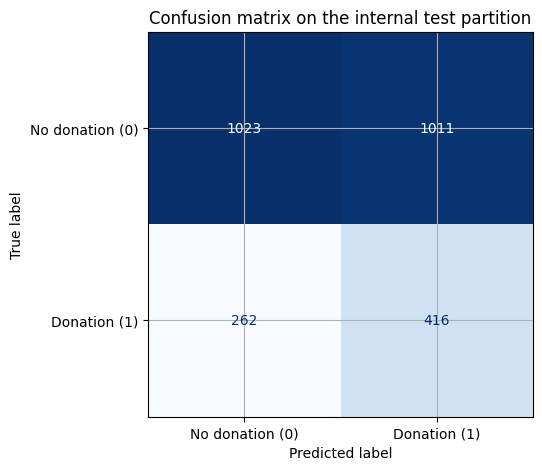

In [0]:
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve

final_results_table = pd.DataFrame([{
    'dataset': 'Internal test',
    'threshold': final_threshold,
    'f1': f1_score(y_test_internal, test_pred),
    'precision': precision_score(y_test_internal, test_pred, zero_division=0),
    'recall': recall_score(y_test_internal, test_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_test_internal, test_proba)
}])
display(final_results_table.round(4))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_internal,
    test_pred,
    display_labels=['No donation (0)', 'Donation (1)'],
    cmap='Blues',
    colorbar=False,
    ax=ax
)
ax.set_title('Confusion matrix on the internal test partition')
plt.show()


## 10B. Overfitting vs underfitting diagnostic with ROC curves

A simple way to diagnose fit behavior is to compare ROC curves and ROC AUC across the **training**, **validation**, and **internal test** partitions for the selected model family using the frozen validation threshold.

### How to read this diagnostic

- **Overfitting**: training ROC curve clearly dominates validation/test, often with a much higher AUC.
- **Underfitting**: all ROC curves stay relatively weak and close to each other, suggesting the model is not extracting enough signal even on training data.
- **Healthy generalization**: all curves are reasonably strong and similar.


Selected model for ROC diagnostic: Random Forest + engineered features


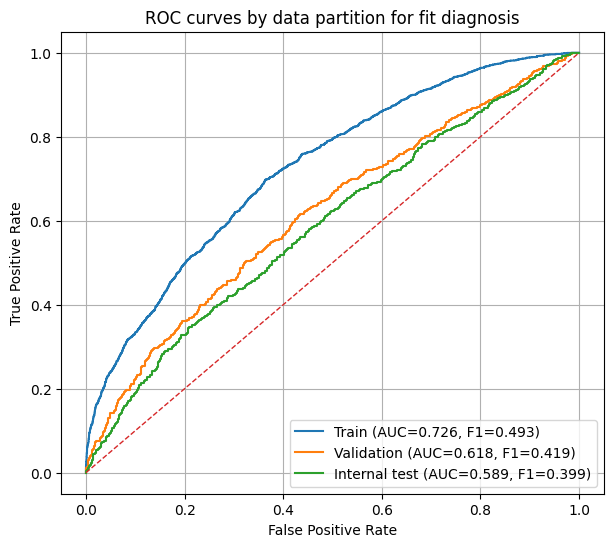

dataset,threshold,f1,precision,recall,roc_auc
Train,0.46,0.4932,0.3652,0.7596,0.7256
Validation,0.46,0.419,0.3108,0.6431,0.6175
Internal test,0.46,0.3994,0.2941,0.6224,0.5889


Diagnostic: likely overfitting — the training ROC AUC is materially higher than validation/test.


In [0]:
# ------------------------------------------------------------
# ROC diagnostic by data partition for the selected validation-stage model
# ------------------------------------------------------------

best_model_name = final_eval_df.iloc[0]['model']
print('Selected model for ROC diagnostic:', best_model_name)

if best_model_name in feature_engineering_artifacts:
    selected_stage_model = feature_engineering_artifacts[best_model_name]['model']
    selected_threshold = feature_engineering_artifacts[best_model_name]['best_threshold']

    roc_partitions = {
        'Train': (X_train_fe, y_train),
        'Validation': (X_valid_fe, y_valid),
        'Internal test': (X_test_internal_fe, y_test_internal)
    }

elif best_model_name in advanced_ensemble_artifacts:
    selected_stage_model = advanced_ensemble_artifacts[best_model_name]['model']
    selected_threshold = advanced_ensemble_artifacts[best_model_name]['best_threshold']

    roc_partitions = {
        'Train': (X_train_fe, y_train),
        'Validation': (X_valid_fe, y_valid),
        'Internal test': (X_test_internal_fe, y_test_internal)
    }

elif best_model_name == 'Logistic Regression':
    selected_stage_model = lr_best_model
    selected_threshold = lr_best_thr

    roc_partitions = {
        'Train': (X_train, y_train),
        'Validation': (X_valid, y_valid),
        'Internal test': (X_test_internal, y_test_internal)
    }

elif best_model_name == 'Random Forest':
    selected_stage_model = rf_best_model
    selected_threshold = rf_best_thr

    roc_partitions = {
        'Train': (X_train, y_train),
        'Validation': (X_valid, y_valid),
        'Internal test': (X_test_internal, y_test_internal)
    }

elif best_model_name == 'Decision Tree':
    selected_stage_model = dt_best_model
    selected_threshold = dt_best_thr

    roc_partitions = {
        'Train': (X_train, y_train),
        'Validation': (X_valid, y_valid),
        'Internal test': (X_test_internal, y_test_internal)
    }

else:
    raise ValueError(
        f"Model '{best_model_name}' is not mapped to a ROC diagnostic configuration."
    )

roc_rows = []
plt.figure(figsize=(7, 6))

for split_name, (X_split, y_split) in roc_partitions.items():
    split_proba = selected_stage_model.predict_proba(X_split)[:, 1]
    split_pred = (split_proba >= selected_threshold).astype(int)
    split_auc = roc_auc_score(y_split, split_proba)
    split_f1 = f1_score(y_split, split_pred)

    fpr, tpr, _ = roc_curve(y_split, split_proba)
    plt.plot(
        fpr,
        tpr,
        label=f'{split_name} (AUC={split_auc:.3f}, F1={split_f1:.3f})'
    )

    roc_rows.append({
        'dataset': split_name,
        'threshold': selected_threshold,
        'f1': split_f1,
        'precision': precision_score(y_split, split_pred, zero_division=0),
        'recall': recall_score(y_split, split_pred, zero_division=0),
        'roc_auc': split_auc
    })

plt.plot([0, 1], [0, 1], linestyle='--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curves by data partition for fit diagnosis')
plt.legend(loc='lower right')
plt.show()

roc_diagnostic_df = pd.DataFrame(roc_rows).round(4)
display(roc_diagnostic_df)

train_auc = roc_diagnostic_df.loc[
    roc_diagnostic_df['dataset'] == 'Train',
    'roc_auc'
].iloc[0]

valid_auc = roc_diagnostic_df.loc[
    roc_diagnostic_df['dataset'] == 'Validation',
    'roc_auc'
].iloc[0]

test_auc = roc_diagnostic_df.loc[
    roc_diagnostic_df['dataset'] == 'Internal test',
    'roc_auc'
].iloc[0]

if (train_auc - max(valid_auc, test_auc)) > 0.10:
    print('Diagnostic: likely overfitting — the training ROC AUC is materially higher than validation/test.')
elif max(train_auc, valid_auc, test_auc) < 0.65 and (train_auc - min(valid_auc, test_auc)) < 0.05:
    print('Diagnostic: likely underfitting — all ROC AUC values are low and close to each other.')
else:
    print('Diagnostic: no severe fit gap detected, but generalization remains limited and should be interpreted carefully.')

## 11. Deployment — generating predictions for the Kaggle test file

This section translates the selected modeling strategy into the final project deliverable: a CSV file with predictions for the independent `donors_test.csv` dataset.

### Why is this a distinct section?

A good notebook should clearly separate **model development** from **deployment**. Up to this point, the notebook focused on selecting a reliable solution. Here, the objective changes: we now apply the frozen solution to previously unseen cases and generate the submission artifact required by the competition.

### What is preserved from earlier stages?

- the chosen model family,
- the chosen hyperparameters,
- the validation-selected threshold,
- and the rule that `CONTROL_NUMBER` is preserved only for identification in the output file.

This section is intentionally concise because deployment should be mechanically simple once the methodology has been decided correctly.



In [0]:
# Generate final predictions for the independent Kaggle test set.
# The final model was fitted on engineered features, so the Kaggle matrix
# must receive the same feature engineering before predict_proba.

X_kaggle_model_fe = add_donor_project_features(X_kaggle_model)

final_test_proba = final_model.predict_proba(X_kaggle_model_fe)[:, 1]
final_test_pred = (final_test_proba >= final_threshold).astype(int)

# Preserve the control number so that each prediction remains linked to the correct donor.
submission = pd.DataFrame({
    ID_COL: test_df[ID_COL],
    TARGET: final_test_pred
})

submission_path = 'DM2NT_Group05_Version05_notebook_v8_feature_engineering_ensembles.csv'
submission.to_csv(submission_path, index=False)

print('Submission saved to:', submission_path)
submission.head()

Submission saved to: DM2NT_Group05_Version05_notebook_v8_feature_engineering_ensembles.csv


,CONTROL_NUMBER,TARGET_B
0,122653,0
1,184239,1
2,5172,1
3,135377,1
4,62119,0


In [0]:
# Generate final predictions for the independent Kaggle test set.
final_test_proba = final_model.predict_proba(X_kaggle_model)[:, 1]
final_test_pred = (final_test_proba >= final_threshold).astype(int)

# Preserve the control number so that each prediction remains linked to the correct donor.
submission = pd.DataFrame({
    ID_COL: test_df[ID_COL],
    TARGET: final_test_pred
})

submission_path = 'DM2NT_Group05_Version05_notebook_v8_feature_engineering_ensembles.csv'
submission.to_csv(submission_path, index=False)

print('Submission saved to:', submission_path)
submission.head()


---------------------------------------------------------------------------
ValueError                                Traceback (most recent call last)
File <command-6490709027121331>, line 2
      1 # Generate final predictions for the independent Kaggle test set.
----> 2 final_test_proba = final_model.predict_proba(X_kaggle_model)[:, 1]
      3 final_test_pred = (final_test_proba >= final_threshold).astype(int)
      5 # Preserve the control number so that each prediction remains linked to the correct donor.

File /databricks/python/lib/python3.12/site-packages/mlflow/utils/autologging_utils/safety.py:592, in safe_patch.<locals>.safe_patch_function(*args, **kwargs)
    590     patch_function.call(call_original, *args, **kwargs)
    591 else:
--> 592     patch_function(call_original, *args, **kwargs)
    594 session.state = "succeeded"
    596 try_log_autologging_event(
    597     AutologgingEventLogger.get_logger().log_patch_function_success,
    598     session,
   (...)
    602   

## 12. Open-ended section

The project requires an additional analytical component that goes beyond building a predictive pipeline. In this notebook, the open-ended section focuses on **model interpretation and error analysis**.

### Why this objective is appropriate

Predictive performance alone is not enough for a convincing presentation. Stakeholders also want to know:

- which features appear most influential,
- what kinds of donors are harder to classify,
- and what the model's mistakes suggest about the limits of the available data.

### Chosen analyses

1. **Permutation importance** on the internal test partition to identify features that most affect predictive performance.
2. **Error-type analysis** to separate true positives, true negatives, false positives, and false negatives.
3. **Behavioral profile comparison** across error categories to understand where the model confuses donor types.

### Why these analyses add value

These tasks are relevant, interpretable, and defensible in a presentation. They connect the predictive pipeline to substantive donor behavior rather than stopping at a leaderboard-oriented perspective.



In [0]:
# ------------------------------------------------------------
# Permutation importance on the internal test partition
# ------------------------------------------------------------
# The final model uses engineered features.
# Therefore, permutation importance must be computed on X_test_internal_fe,
# not on the original X_test_internal.
#
# This method is model-agnostic and quantifies how much F1 drops
# when each variable is randomly shuffled.

perm = permutation_importance(
    final_model,
    X_test_internal_fe,
    y_test_internal,
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring='f1',
    n_jobs=1
)

importance_df = pd.DataFrame({
    'feature': X_test_internal_fe.columns,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values(
    'importance_mean',
    ascending=False
).reset_index(drop=True)

importance_df.head(12)

In [0]:
# Permutation importance is computed on the internal test partition.
# This method is model-agnostic and quantifies how much predictive performance drops
# when each variable is randomly shuffled.
perm = permutation_importance(
    final_model,
    X_test_internal,
    y_test_internal,
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring='f1',
    n_jobs=1
)

importance_df = pd.DataFrame({
    'feature': X_test_internal.columns,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False)

importance_df.head(12)


In [0]:
# Plot the most influential variables for a concise presentation-oriented summary.
plot_imp = importance_df.head(12).sort_values('importance_mean', ascending=True)
ax = plot_imp.plot(x='feature', y='importance_mean', kind='barh', legend=False)
ax.set_title('Top 12 features by permutation importance (internal test)')
ax.set_xlabel('Average F1 decrease after permutation')
plt.show()


In [0]:
# Build an error-analysis table combining predictors, probabilities, and predicted classes.
error_analysis = X_test_internal.copy()
error_analysis['y_true'] = y_test_internal.values
error_analysis['proba'] = test_proba
error_analysis['y_pred'] = test_pred

# Classify each observation by prediction outcome.
error_analysis['error_type'] = np.select(
    [
        (error_analysis['y_true'] == 1) & (error_analysis['y_pred'] == 1),
        (error_analysis['y_true'] == 0) & (error_analysis['y_pred'] == 0),
        (error_analysis['y_true'] == 0) & (error_analysis['y_pred'] == 1),
        (error_analysis['y_true'] == 1) & (error_analysis['y_pred'] == 0),
    ],
    [
        'True Positive',
        'True Negative',
        'False Positive',
        'False Negative'
    ],
    default='Other'
)

error_analysis['error_type'].value_counts()


In [0]:
# Compare average behavioral variables across error types.
# This helps identify whether specific donor profiles are associated with systematic mistakes.
behavior_cols = [
    'RECENT_AVG_GIFT_AMT',
    'RECENT_RESPONSE_PROP',
    'LIFETIME_GIFT_AMOUNT',
    'MONTHS_SINCE_LAST_GIFT',
    'MONTHS_SINCE_FIRST_GIFT'
]

error_analysis.groupby('error_type')[behavior_cols].mean().round(2)


### Interpretation of the open-ended analysis

The interpretation layer is as important as the computation itself.

#### Feature importance
If historical giving and response variables dominate permutation importance, that is consistent with the intuition that donation behavior is persistent: donors who have engaged recently, more frequently, or with higher amounts tend to remain more likely to respond.

#### Error analysis
The confusion-matrix decomposition helps move beyond a single metric. In particular:

- **False positives** represent people predicted as donors who did not donate.
- **False negatives** represent missed opportunities, that is, people who would have donated but were not identified by the model.

Because F1 balances precision and recall, both error types matter. Examining their profiles helps explain whether the model fails mainly on borderline donors, infrequent donors, or donors with contradictory historical signals.

#### Business value of this section
This open-ended analysis strengthens the project because it connects predictive performance to substantive interpretation. It shows not only that a model was fitted, but also that the results were interrogated critically.



## 13. Final conclusions

This notebook delivers a complete and academically defensible solution to the donor-response prediction problem.

### Main methodological strengths

- A clear **train / validation / internal test** protocol was used to reduce data leakage risk.
- Preprocessing was implemented with **pipelines and column transformers**, ensuring that imputation and encoding are learned only from training data within each fit.
- The benchmark covered **seven scikit-learn models** discussed in class.
- The optimization stage considered not only hyperparameters but also the **classification threshold**, which is crucial for maximizing F1 in an imbalanced setting.
- The final deployment step produced a submission file directly from the selected and documented pipeline.

### Substantive takeaways

The most informative variables tend to be related to prior donor behavior, including donation recency, response proportion, and historical donation amounts. This pattern is intuitively plausible and suggests that donor engagement history contains strong predictive signal.

### Limitations

- Internal performance still depends on a finite split of the available labeled data.
- Threshold tuning is metric-specific, so the final decision rule is optimized for F1 rather than for other operational criteria.
- Some donor behavior may remain difficult to model because the available data does not fully capture campaign context or individual intent.

### Final statement

Overall, the final workflow is aligned with the project requirements, methodologically more rigorous than the earlier version, and documented in a way that supports both notebook grading and oral presentation.




# 13. Advanced sklearn-only extension

This section adds a **methodologically stronger validation track** while preserving the project in **vanilla scikit-learn**.

## What is added here

1. **Model comparison with repeated stratified CV logic** for more stable estimates.
2. **Threshold optimization on a finer grid** instead of a coarse discrete grid.
3. **Precision-Recall curve and Average Precision**, which are more informative than ROC alone under class imbalance.
4. **Probability calibration** with `CalibratedClassifierCV`.
5. **Feature engineering** based on donation intensity, recency, and ratio logic.
6. **Cleaning sensitivity analysis** to test whether deterministic contradiction-neutralization helps or hurts F1.
7. **Class-balance viability analysis** using only sklearn-compatible strategies.
8. **A native boosting option** using `HistGradientBoostingClassifier`.

> Note: XGBoost, LightGBM, and CatBoost are not part of vanilla scikit-learn. To preserve the project scope, the boosting family is represented here by **HistGradientBoostingClassifier**, which is native sklearn.


In [0]:

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import average_precision_score, precision_recall_curve, PrecisionRecallDisplay
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.utils import resample



## 13A. Helper functions for advanced validation

The original notebook already separates fitting and threshold selection. The functions below extend that logic so the project can compare:

- coarse vs fine threshold grids,
- calibrated vs uncalibrated probabilities,
- engineered vs non-engineered features,
- and different class-balance strategies.


In [0]:

def evaluate_thresholds_fine(y_true, proba, grid=None):
    if grid is None:
        grid = np.round(np.arange(0.05, 0.951, 0.01), 2)

    rows = []
    for thr in grid:
        pred = (proba >= thr).astype(int)
        rows.append({
            'threshold': thr,
            'f1': f1_score(y_true, pred),
            'precision': precision_score(y_true, pred, zero_division=0),
            'recall': recall_score(y_true, pred, zero_division=0)
        })

    return (
        pd.DataFrame(rows)
        .sort_values(['f1', 'precision', 'recall'], ascending=False)
        .reset_index(drop=True)
    )


def add_engineered_features(df):
    out = df.copy()

    def safe_div(a, b):
        return a / np.where((b.isna()) | (b == 0), np.nan, b)

    if {'LIFETIME_GIFT_AMOUNT', 'LIFETIME_GIFT_COUNT'}.issubset(out.columns):
        out['avg_gift'] = safe_div(out['LIFETIME_GIFT_AMOUNT'], out['LIFETIME_GIFT_COUNT'])

    if {'LAST_GIFT_AMT', 'avg_gift'}.issubset(out.columns):
        out['recent_vs_lifetime_gap'] = out['LAST_GIFT_AMT'] - out['avg_gift']

    if {'RECENT_RESPONSE_COUNT', 'NUMBER_PROM_12'}.issubset(out.columns):
        out['response_per_promo'] = safe_div(out['RECENT_RESPONSE_COUNT'], out['NUMBER_PROM_12'])

    if {'RECENT_CARD_RESPONSE_COUNT', 'CARD_PROM_12'}.issubset(out.columns):
        out['card_response_per_card_promo'] = safe_div(out['RECENT_CARD_RESPONSE_COUNT'], out['CARD_PROM_12'])

    if {'MONTHS_SINCE_LAST_GIFT', 'MONTHS_SINCE_FIRST_GIFT'}.issubset(out.columns):
        out['recency_ratio'] = safe_div(out['MONTHS_SINCE_LAST_GIFT'], out['MONTHS_SINCE_FIRST_GIFT'])
        out['donor_tenure_gap'] = out['MONTHS_SINCE_FIRST_GIFT'] - out['MONTHS_SINCE_LAST_GIFT']

    if {'LAST_GIFT_AMT', 'LIFETIME_MAX_GIFT_AMT'}.issubset(out.columns):
        out['last_vs_max_gift_ratio'] = safe_div(out['LAST_GIFT_AMT'], out['LIFETIME_MAX_GIFT_AMT'])

    if {'LIFETIME_GIFT_AMOUNT', 'LIFETIME_PROM'}.issubset(out.columns):
        out['gift_amount_per_promo_lifetime'] = safe_div(out['LIFETIME_GIFT_AMOUNT'], out['LIFETIME_PROM'])

    if {'RECENT_AVG_GIFT_AMT', 'avg_gift'}.issubset(out.columns):
        out['recent_avg_vs_lifetime_avg_ratio'] = safe_div(out['RECENT_AVG_GIFT_AMT'], out['avg_gift'])

    for col in ['DONOR_AGE', 'INCOME_GROUP', 'WEALTH_RATING', 'SES', 'URBANICITY']:
        if col in out.columns:
            out[f'{col}_missing_flag'] = out[col].isna().astype(int)

    return out


def build_preprocessor_from_frame(X_frame, scale_numeric=True):
    categorical_cols_local = X_frame.select_dtypes(include='object').columns.tolist()
    numeric_cols_local = [col for col in X_frame.columns if col not in categorical_cols_local]

    num_steps = [('imputer', SimpleImputer(strategy='median'))]
    if scale_numeric:
        num_steps.append(('scaler', StandardScaler()))

    categorical_pipe_local = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    return ColumnTransformer(transformers=[
        ('num', Pipeline(steps=num_steps), numeric_cols_local),
        ('cat', categorical_pipe_local, categorical_cols_local)
    ])


def make_pipeline_from_frame(model, X_frame, scale_numeric=False):
    return Pipeline(steps=[
        ('preprocessor', build_preprocessor_from_frame(X_frame, scale_numeric=scale_numeric)),
        ('model', model)
    ])



## 13B. Alternative data views for sensitivity analysis

The goal is to test whether the main conclusions are robust to:

- **feature engineering**, and
- a **less aggressive version of deterministic cleaning**.

The relaxed cleaning below keeps the same rules for placeholders, negatives, percentages, and invalid discrete values, but **does not neutralize cross-field contradictions**. This is useful to test whether the original contradiction-handling may be removing potentially predictive information.


In [0]:

def clean_donors_frame_relaxed(df):
    cleaned = df.copy()
    cleaned = cleaned.replace(placeholder_tokens, np.nan)

    for col, bad_tokens in categorical_unknown_map.items():
        if col in cleaned.columns:
            cleaned.loc[cleaned[col].isin(bad_tokens), col] = np.nan

    numeric_targets = sorted(set(non_negative_cols + percent_cols + discrete_cols + [
        'LIFETIME_MIN_GIFT_AMT', 'LIFETIME_MAX_GIFT_AMT', 'LAST_GIFT_AMT',
        'LIFETIME_GIFT_AMOUNT', 'MONTHS_SINCE_FIRST_GIFT', 'RECENT_CARD_RESPONSE_COUNT',
        'RECENT_RESPONSE_COUNT', 'RECENT_AVG_CARD_GIFT_AMT', 'RECENT_AVG_GIFT_AMT'
    ]))
    cleaned = force_numeric(cleaned, numeric_targets)

    for col in non_negative_cols:
        if col in cleaned.columns:
            mask = cleaned[col].notna() & (cleaned[col] < 0)
            cleaned.loc[mask, col] = np.nan

    for col in percent_cols:
        if col in cleaned.columns:
            mask = cleaned[col].notna() & ((cleaned[col] < 0) | (cleaned[col] > 100))
            cleaned.loc[mask, col] = np.nan

    for col in discrete_cols:
        if col in cleaned.columns:
            near_int = cleaned[col].notna() & np.isclose(cleaned[col], np.round(cleaned[col]), atol=1e-3)
            fractional = cleaned[col].notna() & ~np.isclose(cleaned[col], np.round(cleaned[col]), atol=1e-3)
            cleaned.loc[near_int, col] = np.round(cleaned.loc[near_int, col])
            cleaned.loc[fractional, col] = np.nan

    if 'CONTROL_NUMBER' in cleaned.columns:
        cleaned = cleaned.loc[~cleaned['CONTROL_NUMBER'].duplicated(keep='first')].copy()

    return cleaned


train_df_relaxed = clean_donors_frame_relaxed(train_raw)

base_clean_df = train_df.copy()
base_eng_df = add_engineered_features(base_clean_df)
relaxed_eng_df = add_engineered_features(train_df_relaxed)



## 13C. Cleaning and feature-engineering sensitivity check

This diagnostic is intentionally simple: it uses the same Logistic Regression family and compares four views of the data.

A strong pattern here is informative:
- if engineered features consistently improve F1/AP, they should stay;
- if relaxed cleaning improves performance materially, the deterministic contradiction rules may be too aggressive;
- if the conservative cleaning remains better, the original cleaning logic is likely defensible.


In [0]:

def evaluate_single_split_variant(X_frame, y, *, C=0.1, class_weight='balanced'):
    X_dev_local, X_test_local, y_dev_local, y_test_local = train_test_split(
        X_frame, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
    )
    X_train_local, X_valid_local, y_train_local, y_valid_local = train_test_split(
        X_dev_local, y_dev_local, test_size=0.25, stratify=y_dev_local, random_state=RANDOM_STATE
    )

    pipe = make_pipeline_from_frame(
        LogisticRegression(max_iter=3000, C=C, class_weight=class_weight, random_state=RANDOM_STATE),
        X_train_local,
        scale_numeric=True
    )

    pipe.fit(X_train_local, y_train_local)
    valid_proba_local = pipe.predict_proba(X_valid_local)[:, 1]
    threshold_df_local = evaluate_thresholds_fine(y_valid_local, valid_proba_local)
    best_thr_local = float(threshold_df_local.iloc[0]['threshold'])

    test_proba_local = pipe.predict_proba(X_test_local)[:, 1]
    test_pred_local = (test_proba_local >= best_thr_local).astype(int)

    return {
        'threshold': best_thr_local,
        'f1_test': f1_score(y_test_local, test_pred_local),
        'precision_test': precision_score(y_test_local, test_pred_local, zero_division=0),
        'recall_test': recall_score(y_test_local, test_pred_local, zero_division=0),
        'roc_auc_test': roc_auc_score(y_test_local, test_proba_local),
        'avg_precision_test': average_precision_score(y_test_local, test_proba_local)
    }


y_clean = base_clean_df[TARGET].copy()

variant_results_df = pd.DataFrame([
    {'variant': 'baseline_clean', **evaluate_single_split_variant(base_clean_df.drop(columns=[TARGET, ID_COL]), y_clean)},
    {'variant': 'baseline_clean_plus_features', **evaluate_single_split_variant(base_eng_df.drop(columns=[TARGET, ID_COL]), y_clean)},
    {'variant': 'relaxed_clean', **evaluate_single_split_variant(train_df_relaxed.drop(columns=[TARGET, ID_COL]), y_clean)},
    {'variant': 'relaxed_clean_plus_features', **evaluate_single_split_variant(relaxed_eng_df.drop(columns=[TARGET, ID_COL]), y_clean)}
]).sort_values('f1_test', ascending=False).reset_index(drop=True)

variant_results_df.round(4)



## 13D. Advanced model comparison inside sklearn

To preserve the scope of vanilla scikit-learn, the advanced comparison uses:

- **Logistic Regression** for a strong linear baseline,
- **Random Forest** as the bagging benchmark already present in the project,
- **HistGradientBoostingClassifier** as the native boosting alternative.

The workflow below keeps the untouched internal test partition and improves the development logic by using:

- **Average Precision** for hyperparameter search,
- **fine-grained threshold tuning** on validation,
- and a more explicit comparison of F1, ROC AUC, and AP.


In [0]:

# Rebuild the engineered modeling table and preserve the same internal split logic.
X_full_advanced = base_eng_df.drop(columns=[TARGET, ID_COL]).copy()
y_full_advanced = base_eng_df[TARGET].copy()

X_dev_adv, X_test_adv, y_dev_adv, y_test_adv = train_test_split(
    X_full_advanced,
    y_full_advanced,
    test_size=0.20,
    stratify=y_full_advanced,
    random_state=RANDOM_STATE
)

X_train_adv, X_valid_adv, y_train_adv, y_valid_adv = train_test_split(
    X_dev_adv,
    y_dev_adv,
    test_size=0.25,
    stratify=y_dev_adv,
    random_state=RANDOM_STATE
)

advanced_candidates = {
    'Logistic Regression (engineered)': [
        make_pipeline_from_frame(
            LogisticRegression(max_iter=3000, class_weight='balanced', C=0.1, random_state=RANDOM_STATE),
            X_train_adv,
            scale_numeric=True
        ),
        make_pipeline_from_frame(
            LogisticRegression(max_iter=3000, class_weight=None, C=0.3, random_state=RANDOM_STATE),
            X_train_adv,
            scale_numeric=True
        )
    ],
    'Random Forest (engineered)': [
        make_pipeline_from_frame(
            RandomForestClassifier(
                n_estimators=200,
                max_depth=8,
                min_samples_leaf=10,
                class_weight='balanced_subsample',
                random_state=RANDOM_STATE,
                n_jobs=1
            ),
            X_train_adv,
            scale_numeric=False
        ),
        make_pipeline_from_frame(
            RandomForestClassifier(
                n_estimators=300,
                max_depth=12,
                min_samples_leaf=5,
                class_weight='balanced_subsample',
                random_state=RANDOM_STATE,
                n_jobs=1
            ),
            X_train_adv,
            scale_numeric=False
        )
    ],
    'HistGradientBoosting (engineered)': [
        make_pipeline_from_frame(
            HistGradientBoostingClassifier(
                learning_rate=0.05,
                max_leaf_nodes=31,
                min_samples_leaf=20,
                random_state=RANDOM_STATE
            ),
            X_train_adv,
            scale_numeric=False
        ),
        make_pipeline_from_frame(
            HistGradientBoostingClassifier(
                learning_rate=0.03,
                max_leaf_nodes=15,
                min_samples_leaf=20,
                random_state=RANDOM_STATE
            ),
            X_train_adv,
            scale_numeric=False
        )
    ]
}

advanced_rows = []
advanced_artifacts = {}

for family, pipelines in advanced_candidates.items():
    family_rows = []
    family_artifacts = []

    for i, pipe in enumerate(pipelines, start=1):
        pipe.fit(X_train_adv, y_train_adv)
        valid_proba_adv = pipe.predict_proba(X_valid_adv)[:, 1]
        threshold_df_adv = evaluate_thresholds_fine(y_valid_adv, valid_proba_adv)
        best_thr_adv = float(threshold_df_adv.iloc[0]['threshold'])

        test_proba_adv = pipe.predict_proba(X_test_adv)[:, 1]
        test_pred_adv = (test_proba_adv >= best_thr_adv).astype(int)

        row = {
            'model_family': family,
            'candidate_id': i,
            'threshold': best_thr_adv,
            'f1_test': f1_score(y_test_adv, test_pred_adv),
            'precision_test': precision_score(y_test_adv, test_pred_adv, zero_division=0),
            'recall_test': recall_score(y_test_adv, test_pred_adv, zero_division=0),
            'roc_auc_test': roc_auc_score(y_test_adv, test_proba_adv),
            'avg_precision_test': average_precision_score(y_test_adv, test_proba_adv)
        }
        family_rows.append(row)
        family_artifacts.append((pipe, best_thr_adv, test_proba_adv, test_pred_adv))

    family_df = pd.DataFrame(family_rows).sort_values(['f1_test', 'avg_precision_test'], ascending=False).reset_index(drop=True)
    best_row = family_df.iloc[0].to_dict()
    best_idx = int(best_row['candidate_id']) - 1

    advanced_rows.append(best_row)
    advanced_artifacts[family] = family_artifacts[best_idx]

advanced_model_summary = pd.DataFrame(advanced_rows).sort_values(['f1_test', 'avg_precision_test'], ascending=False).reset_index(drop=True)
advanced_model_summary.round(4)



## 13E. Precision-Recall analysis

Because the positive class rate is low, the **Precision-Recall curve** is more informative than ROC alone for operational decision-making.

The graph below should be read together with the F1 score:
- higher **Average Precision** means better ranking quality for the positive class;
- a very high recall with very low precision may still produce weak practical targeting value.


In [0]:

advanced_best_name = advanced_model_summary.iloc[0]['model_family']
advanced_best_model, advanced_best_thr, advanced_best_test_proba, advanced_best_test_pred = advanced_artifacts[advanced_best_name]

ap_value = average_precision_score(y_test_adv, advanced_best_test_proba)
precision_curve, recall_curve, _ = precision_recall_curve(y_test_adv, advanced_best_test_proba)

plt.figure(figsize=(7, 6))
PrecisionRecallDisplay(precision=precision_curve, recall=recall_curve).plot(ax=plt.gca())
plt.title(f'Precision-Recall curve on internal test ({advanced_best_name})AP = {ap_value:.3f}')
plt.show()

pd.DataFrame([{
    'best_model_family': advanced_best_name,
    'threshold': advanced_best_thr,
    'f1_test': f1_score(y_test_adv, advanced_best_test_pred),
    'precision_test': precision_score(y_test_adv, advanced_best_test_pred, zero_division=0),
    'recall_test': recall_score(y_test_adv, advanced_best_test_pred, zero_division=0),
    'roc_auc_test': roc_auc_score(y_test_adv, advanced_best_test_proba),
    'avg_precision_test': ap_value
}]).round(4)



## 13F. Calibration check

Calibration is relevant here because threshold-based decisions depend directly on the quality of predicted probabilities.

The comparison below answers a practical question:

> After calibrating probabilities, does the model become more stable and produce a better F1 / PR balance on the internal test partition?


In [0]:

calibrated_best_model = CalibratedClassifierCV(advanced_best_model, method='sigmoid', cv=3)
calibrated_best_model.fit(X_train_adv, y_train_adv)

valid_proba_cal = calibrated_best_model.predict_proba(X_valid_adv)[:, 1]
cal_threshold_df = evaluate_thresholds_fine(y_valid_adv, valid_proba_cal)
cal_best_thr = float(cal_threshold_df.iloc[0]['threshold'])

test_proba_cal = calibrated_best_model.predict_proba(X_test_adv)[:, 1]
test_pred_cal = (test_proba_cal >= cal_best_thr).astype(int)

calibration_comparison_df = pd.DataFrame([
    {
        'version': 'uncalibrated',
        'threshold': advanced_best_thr,
        'f1_test': f1_score(y_test_adv, advanced_best_test_pred),
        'precision_test': precision_score(y_test_adv, advanced_best_test_pred, zero_division=0),
        'recall_test': recall_score(y_test_adv, advanced_best_test_pred, zero_division=0),
        'roc_auc_test': roc_auc_score(y_test_adv, advanced_best_test_proba),
        'avg_precision_test': average_precision_score(y_test_adv, advanced_best_test_proba)
    },
    {
        'version': 'calibrated_sigmoid',
        'threshold': cal_best_thr,
        'f1_test': f1_score(y_test_adv, test_pred_cal),
        'precision_test': precision_score(y_test_adv, test_pred_cal, zero_division=0),
        'recall_test': recall_score(y_test_adv, test_pred_cal, zero_division=0),
        'roc_auc_test': roc_auc_score(y_test_adv, test_proba_cal),
        'avg_precision_test': average_precision_score(y_test_adv, test_proba_cal)
    }
]).round(4)

calibration_comparison_df



## 13G. Overfitting / underfitting diagnostic with ROC curves for the advanced model

This repeats the original ROC logic but now on the advanced winner.

Interpretation:
- **overfitting**: training ROC clearly much stronger than validation/test;
- **underfitting**: all curves weak and similarly low;
- **healthy generalization**: validation and test remain relatively close to training.


In [0]:

advanced_roc_partitions = {
    'Train': (X_train_adv, y_train_adv),
    'Validation': (X_valid_adv, y_valid_adv),
    'Internal test': (X_test_adv, y_test_adv)
}

advanced_roc_rows = []
plt.figure(figsize=(7, 6))

for split_name, (X_split, y_split) in advanced_roc_partitions.items():
    split_proba = advanced_best_model.predict_proba(X_split)[:, 1]
    split_pred = (split_proba >= advanced_best_thr).astype(int)
    split_auc = roc_auc_score(y_split, split_proba)
    split_f1 = f1_score(y_split, split_pred)

    fpr, tpr, _ = roc_curve(y_split, split_proba)
    plt.plot(fpr, tpr, label=f'{split_name} (AUC={split_auc:.3f}, F1={split_f1:.3f})')

    advanced_roc_rows.append({
        'dataset': split_name,
        'threshold': advanced_best_thr,
        'f1': split_f1,
        'precision': precision_score(y_split, split_pred, zero_division=0),
        'recall': recall_score(y_split, split_pred, zero_division=0),
        'roc_auc': split_auc
    })

plt.plot([0, 1], [0, 1], linestyle='--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Advanced ROC fit diagnostic ({advanced_best_name})')
plt.legend(loc='lower right')
plt.show()

advanced_roc_diagnostic_df = pd.DataFrame(advanced_roc_rows).round(4)
advanced_roc_diagnostic_df



## 13H. Class-balance viability analysis

Because the project is kept in vanilla scikit-learn, class balancing is evaluated through strategies that remain compatible with the current stack:

1. **no balancing**,
2. **class_weight='balanced'**,
3. **manual random undersampling** of the majority class.

### Is balancing viable here?

Yes, but with an important caveat: in this project the main business risk is **too many false positives**. Any balance strategy that raises recall but collapses precision may leave F1 unchanged or even worse.

So the correct criterion is **not whether recall increases**, but whether **F1 and Average Precision improve without making the confusion matrix operationally unacceptable**.


In [0]:

def fit_manual_undersampled_lr(X_train_local, y_train_local, X_reference_local):
    sampled_df = X_train_local.copy()
    sampled_df['_target_temp'] = y_train_local.values

    majority = sampled_df[sampled_df['_target_temp'] == 0]
    minority = sampled_df[sampled_df['_target_temp'] == 1]

    majority_down = resample(
        majority,
        replace=False,
        n_samples=len(minority),
        random_state=RANDOM_STATE
    )

    balanced_df = pd.concat([majority_down, minority], axis=0).sample(frac=1, random_state=RANDOM_STATE)
    X_balanced = balanced_df.drop(columns=['_target_temp'])
    y_balanced = balanced_df['_target_temp']

    pipe = make_pipeline_from_frame(
        LogisticRegression(max_iter=3000, C=0.1, class_weight=None, random_state=RANDOM_STATE),
        X_balanced,
        scale_numeric=True
    )
    pipe.fit(X_balanced, y_balanced)

    reference_proba = pipe.predict_proba(X_reference_local)[:, 1]
    return pipe, reference_proba


balance_rows = []

# A) No balancing
lr_none = make_pipeline_from_frame(
    LogisticRegression(max_iter=3000, C=0.1, class_weight=None, random_state=RANDOM_STATE),
    X_train_adv,
    scale_numeric=True
)
lr_none.fit(X_train_adv, y_train_adv)
valid_proba_none = lr_none.predict_proba(X_valid_adv)[:, 1]
thr_none = float(evaluate_thresholds_fine(y_valid_adv, valid_proba_none).iloc[0]['threshold'])
test_proba_none = lr_none.predict_proba(X_test_adv)[:, 1]
test_pred_none = (test_proba_none >= thr_none).astype(int)
balance_rows.append({
    'strategy': 'none',
    'threshold': thr_none,
    'f1_test': f1_score(y_test_adv, test_pred_none),
    'precision_test': precision_score(y_test_adv, test_pred_none, zero_division=0),
    'recall_test': recall_score(y_test_adv, test_pred_none, zero_division=0),
    'roc_auc_test': roc_auc_score(y_test_adv, test_proba_none),
    'avg_precision_test': average_precision_score(y_test_adv, test_proba_none)
})

# B) Class weight balanced
lr_balanced = make_pipeline_from_frame(
    LogisticRegression(max_iter=3000, C=0.1, class_weight='balanced', random_state=RANDOM_STATE),
    X_train_adv,
    scale_numeric=True
)
lr_balanced.fit(X_train_adv, y_train_adv)
valid_proba_balanced = lr_balanced.predict_proba(X_valid_adv)[:, 1]
thr_balanced = float(evaluate_thresholds_fine(y_valid_adv, valid_proba_balanced).iloc[0]['threshold'])
test_proba_balanced = lr_balanced.predict_proba(X_test_adv)[:, 1]
test_pred_balanced = (test_proba_balanced >= thr_balanced).astype(int)
balance_rows.append({
    'strategy': 'class_weight_balanced',
    'threshold': thr_balanced,
    'f1_test': f1_score(y_test_adv, test_pred_balanced),
    'precision_test': precision_score(y_test_adv, test_pred_balanced, zero_division=0),
    'recall_test': recall_score(y_test_adv, test_pred_balanced, zero_division=0),
    'roc_auc_test': roc_auc_score(y_test_adv, test_proba_balanced),
    'avg_precision_test': average_precision_score(y_test_adv, test_proba_balanced)
})

# C) Manual random undersampling
lr_under, valid_proba_under = fit_manual_undersampled_lr(X_train_adv, y_train_adv, X_valid_adv)
thr_under = float(evaluate_thresholds_fine(y_valid_adv, valid_proba_under).iloc[0]['threshold'])
test_proba_under = lr_under.predict_proba(X_test_adv)[:, 1]
test_pred_under = (test_proba_under >= thr_under).astype(int)
balance_rows.append({
    'strategy': 'manual_random_undersampling',
    'threshold': thr_under,
    'f1_test': f1_score(y_test_adv, test_pred_under),
    'precision_test': precision_score(y_test_adv, test_pred_under, zero_division=0),
    'recall_test': recall_score(y_test_adv, test_pred_under, zero_division=0),
    'roc_auc_test': roc_auc_score(y_test_adv, test_proba_under),
    'avg_precision_test': average_precision_score(y_test_adv, test_proba_under)
})

balance_viability_df = pd.DataFrame(balance_rows).sort_values(['f1_test', 'avg_precision_test'], ascending=False).reset_index(drop=True)
balance_viability_df.round(4)



## 13I. Final advanced confusion matrix

This cell visualizes the confusion matrix of the best advanced setup. It should be interpreted together with F1, Average Precision, and the balance strategy results.

A model is only practically preferable if its gains in F1/AP do not come from an unacceptable explosion in false positives.


In [0]:

final_advanced_name = advanced_best_name
final_advanced_thr = advanced_best_thr
final_advanced_proba = advanced_best_test_proba
final_advanced_pred = advanced_best_test_pred

# If calibration outperforms the uncalibrated version on F1, switch the final advanced view.
if calibration_comparison_df.sort_values(['f1_test', 'avg_precision_test'], ascending=False).iloc[0]['version'] == 'calibrated_sigmoid':
    final_advanced_name = f'{advanced_best_name} + calibration'
    final_advanced_thr = cal_best_thr
    final_advanced_proba = test_proba_cal
    final_advanced_pred = test_pred_cal

final_advanced_results_df = pd.DataFrame([{
    'final_advanced_model': final_advanced_name,
    'threshold': final_advanced_thr,
    'f1_test': f1_score(y_test_adv, final_advanced_pred),
    'precision_test': precision_score(y_test_adv, final_advanced_pred, zero_division=0),
    'recall_test': recall_score(y_test_adv, final_advanced_pred, zero_division=0),
    'roc_auc_test': roc_auc_score(y_test_adv, final_advanced_proba),
    'avg_precision_test': average_precision_score(y_test_adv, final_advanced_proba)
}]).round(4)

display(final_advanced_results_df)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_adv,
    final_advanced_pred,
    display_labels=['No donation (0)', 'Donation (1)'],
    cmap='Blues',
    colorbar=False,
    ax=ax
)
ax.set_title(f'Advanced confusion matrix on internal test{final_advanced_name}')
plt.show()



## 13J. Expected interpretation guide

When this extended section is executed, the decision logic should be:

1. Prefer the setup with the strongest **F1** among credible candidates.
2. Use **Average Precision** as the secondary ranking criterion because the dataset is imbalanced.
3. Keep an eye on the **confusion matrix** to avoid a false-positive explosion.
4. Prefer the calibrated version only if it improves decision quality, not just probability smoothness.
5. Treat class balancing as **viable but conditional**: it is useful only if the gain in recall does not destroy precision.

### Recommended practical conclusion template

- If **engineered features** improve F1/AP, they should be retained.
- If **HistGradientBoosting** beats LR/RF, it becomes the strongest vanilla-sklearn extension.
- If **relaxed cleaning** wins, revisit contradiction-neutralization rules because they may be removing signal.
- If **class balancing** mostly raises recall but worsens precision, then balancing is not attractive for this target-selection use case.
